In [1]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO
from collections import Counter, defaultdict
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("CAFA 5 - PROTEIN FUNCTION PREDICTION")
print("="*70)
print("\nOfficial Kaggle Competition Dataset")
print("Competition: https://www.kaggle.com/c/cafa-5-protein-function-prediction")

CAFA 5 - PROTEIN FUNCTION PREDICTION

Official Kaggle Competition Dataset
Competition: https://www.kaggle.com/c/cafa-5-protein-function-prediction


In [2]:
# Cell 2: Load Training Annotations
print("\n" + "="*70)
print("LOADING TRAINING ANNOTATIONS")
print("="*70)

# Load GO term annotations
train_terms = pd.read_csv('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/data/raw/train_terms.tsv', sep='\t')

print(f"\nAnnotations loaded: {len(train_terms):,} rows")
print(f"\nColumn names: {train_terms.columns.tolist()}")
print(f"\nFirst 10 rows:")
print(train_terms.head(10))

print(f"\n📊 DATASET STATISTICS:")
print(f"  Unique proteins: {train_terms['EntryID'].nunique():,}")
print(f"  Unique GO terms: {train_terms['term'].nunique():,}")
print(f"  Total protein-GO pairs: {len(train_terms):,}")

# Separate by ontology
ontologies = train_terms['aspect'].value_counts()
print(f"\n📊 GO TERM CATEGORIES:")
for aspect, count in ontologies.items():
    aspect_name = {'F': 'Molecular Function (MF)',
                   'P': 'Biological Process (BP)', 
                   'C': 'Cellular Component (CC)'}.get(aspect, aspect)
    print(f"  {aspect_name}: {count:,} annotations")


LOADING TRAINING ANNOTATIONS

Annotations loaded: 5,363,863 rows

Column names: ['EntryID', 'term', 'aspect']

First 10 rows:
      EntryID        term aspect
0  A0A009IHW8  GO:0008152    BPO
1  A0A009IHW8  GO:0034655    BPO
2  A0A009IHW8  GO:0072523    BPO
3  A0A009IHW8  GO:0044270    BPO
4  A0A009IHW8  GO:0006753    BPO
5  A0A009IHW8  GO:1901292    BPO
6  A0A009IHW8  GO:0044237    BPO
7  A0A009IHW8  GO:1901360    BPO
8  A0A009IHW8  GO:0008150    BPO
9  A0A009IHW8  GO:1901564    BPO

📊 DATASET STATISTICS:
  Unique proteins: 142,246
  Unique GO terms: 31,466
  Total protein-GO pairs: 5,363,863

📊 GO TERM CATEGORIES:
  BPO: 3,497,732 annotations
  CCO: 1,196,017 annotations
  MFO: 670,114 annotations


In [4]:
print(train_terms.shape)
print(train_terms.head())

(5363863, 3)
      EntryID        term aspect
0  A0A009IHW8  GO:0008152    BPO
1  A0A009IHW8  GO:0034655    BPO
2  A0A009IHW8  GO:0072523    BPO
3  A0A009IHW8  GO:0044270    BPO
4  A0A009IHW8  GO:0006753    BPO


In [5]:
# Cell 3: Analyze GO Term Distribution
print("\n" + "="*70)
print("GO TERM FREQUENCY ANALYSIS")
print("="*70)

# Count proteins per GO term
go_term_counts = train_terms.groupby(['term', 'aspect']).size().reset_index(name='protein_count')
go_term_counts = go_term_counts.sort_values('protein_count', ascending=False)

print("\n📊 TOP 30 MOST COMMON GO TERMS (All Categories):")
print(go_term_counts.head(30).to_string(index=False))

# Separate by aspect
for aspect in ['MFO', 'BPO', 'CCO']:

    aspect_name = {
        'MFO': 'Molecular Function',
        'BPO': 'Biological Process',
        'CCO': 'Cellular Component'
    }[aspect]

    aspect_terms = go_term_counts[go_term_counts['aspect'] == aspect]

    print(f"\n{'='*70}")
    print(f"TOP 20 {aspect_name.upper()} TERMS:")
    print(f"{'='*70}")
    print(aspect_terms.head(20).to_string(index=False))

    aspect_terms.to_csv(
        f'C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/data/processed/GO_{aspect}_frequencies.csv',
        index=False
    )

    print(f"\n✓ Saved: GO_{aspect}_frequencies.csv")


GO TERM FREQUENCY ANALYSIS

📊 TOP 30 MOST COMMON GO TERMS (All Categories):
      term aspect  protein_count
GO:0005575    CCO          92912
GO:0008150    BPO          92210
GO:0110165    CCO          91286
GO:0003674    MFO          78637
GO:0005622    CCO          70785
GO:0009987    BPO          61293
GO:0043226    CCO          60883
GO:0043229    CCO          58315
GO:0005488    MFO          57380
GO:0043227    CCO          55452
GO:0005737    CCO          53193
GO:0043231    CCO          52218
GO:0005515    MFO          47987
GO:0065007    BPO          41457
GO:0050789    BPO          39256
GO:0050794    BPO          33888
GO:0050896    BPO          31098
GO:0008152    BPO          30448
GO:0032501    BPO          29274
GO:0005634    CCO          28932
GO:0032502    BPO          28680
GO:0071704    BPO          28274
GO:0048856    BPO          27366
GO:0016020    CCO          25768
GO:0003824    MFO          25324
GO:0044237    BPO          25273
GO:0044238    BPO          24419

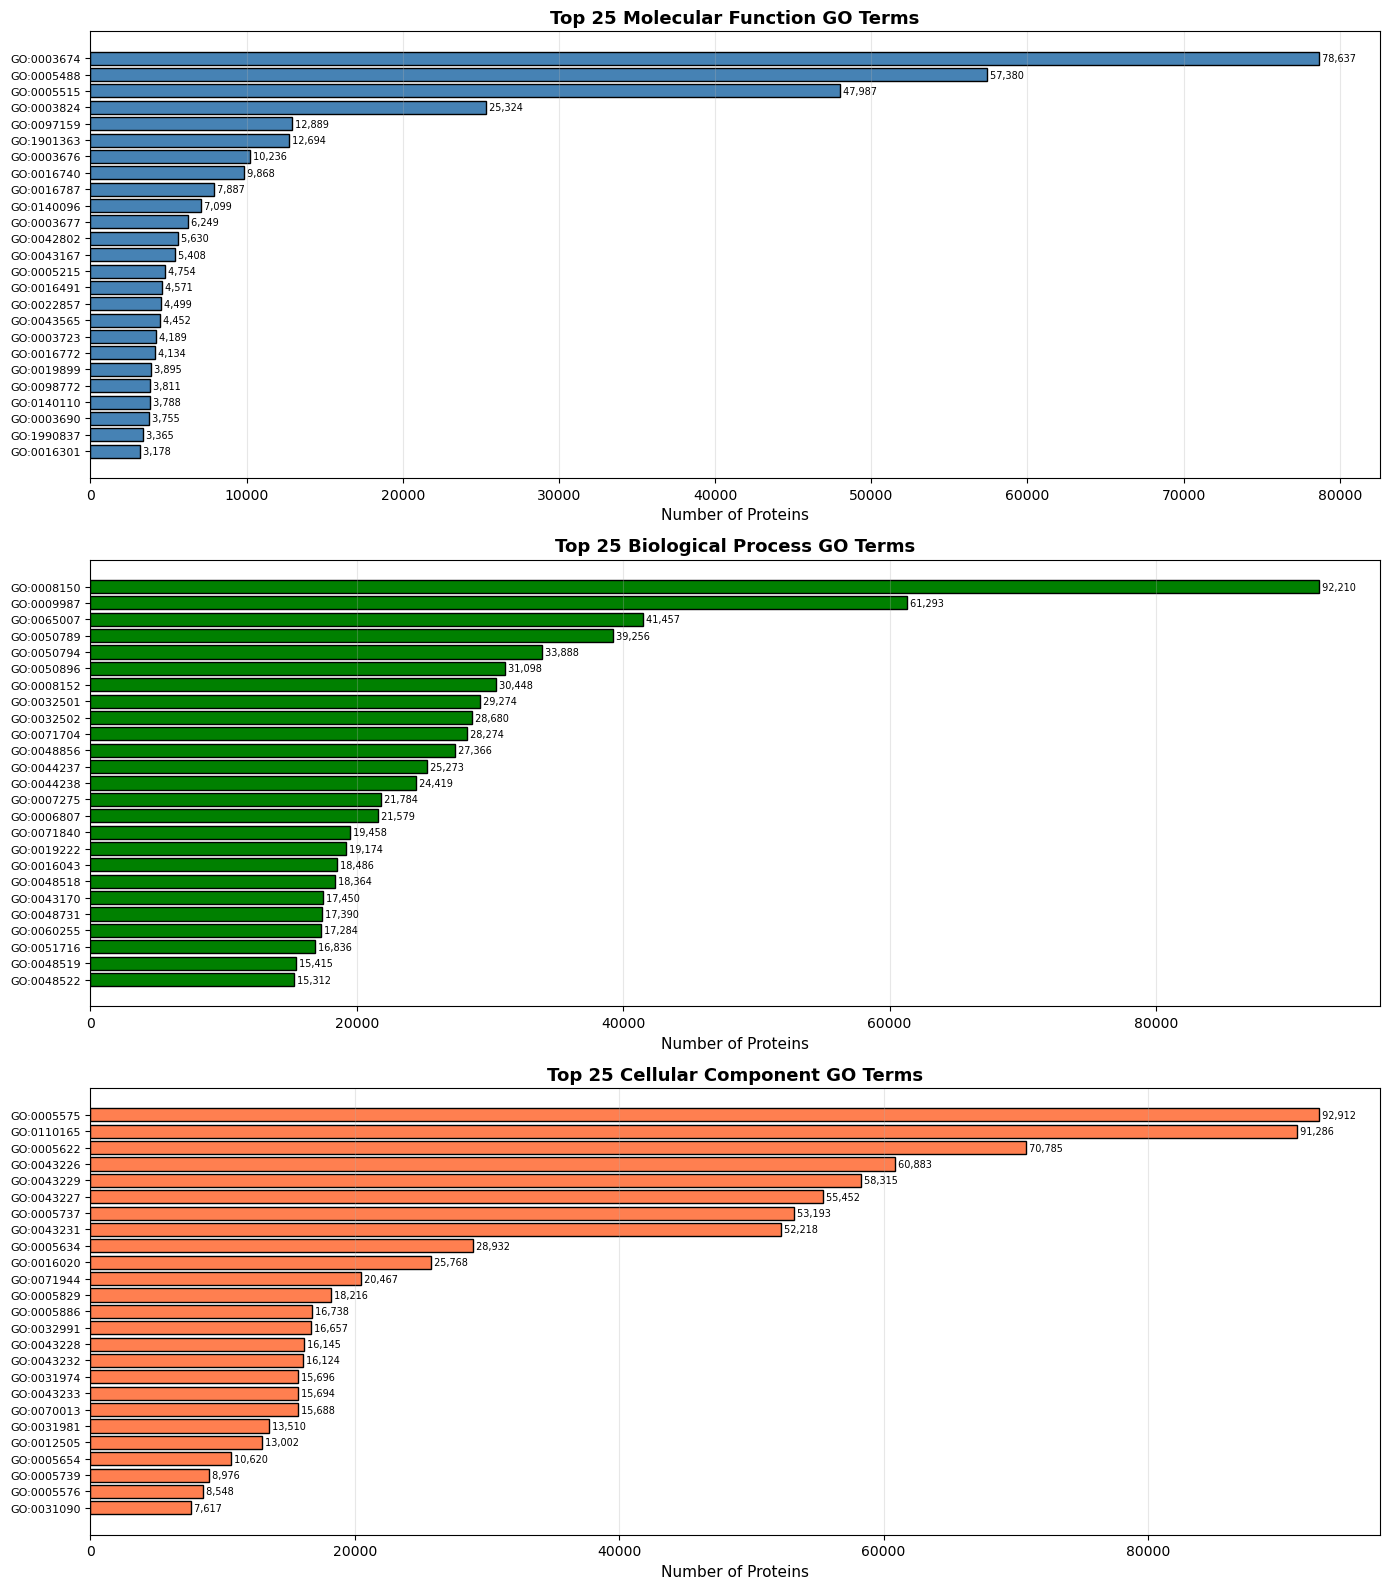


✓ Saved: visuals/01_top_go_terms_by_category.png


In [6]:
# Cell 4: Visualize GO Term Distribution
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 16))

aspects = [
    ('MFO', 'Molecular Function', 'steelblue'),
    ('BPO', 'Biological Process', 'green'),
    ('CCO', 'Cellular Component', 'coral')
]

for idx, (aspect, title, color) in enumerate(aspects):

    # Get top 25 terms for this aspect
    aspect_data = go_term_counts[go_term_counts['aspect'] == aspect].head(25)

    axes[idx].barh(
        range(len(aspect_data)),
        aspect_data['protein_count'],
        color=color,
        edgecolor='black'
    )

    axes[idx].set_yticks(range(len(aspect_data)))
    axes[idx].set_yticklabels(aspect_data['term'], fontsize=8)
    axes[idx].set_xlabel('Number of Proteins', fontsize=11)
    axes[idx].set_title(f'Top 25 {title} GO Terms', fontsize=13, fontweight='bold')
    axes[idx].invert_yaxis()
    axes[idx].grid(axis='x', alpha=0.3)

    # Add value labels
    for i, v in enumerate(aspect_data['protein_count']):
        axes[idx].text(v, i, f' {v:,}', va='center', fontsize=7)

plt.tight_layout()

# Ensure folder exists
import os
os.makedirs('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/visuals', exist_ok=True)

plt.savefig('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/visuals/01_top_go_terms_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: visuals/01_top_go_terms_by_category.png")



NUMBER OF GO TERMS PER PROTEIN

📊 GO TERMS PER PROTEIN STATISTICS:
count    142246.000000
mean         37.708357
std          42.524701
min           2.000000
25%          10.000000
50%          24.000000
75%          50.000000
max         815.000000
Name: total_GO_terms, dtype: float64


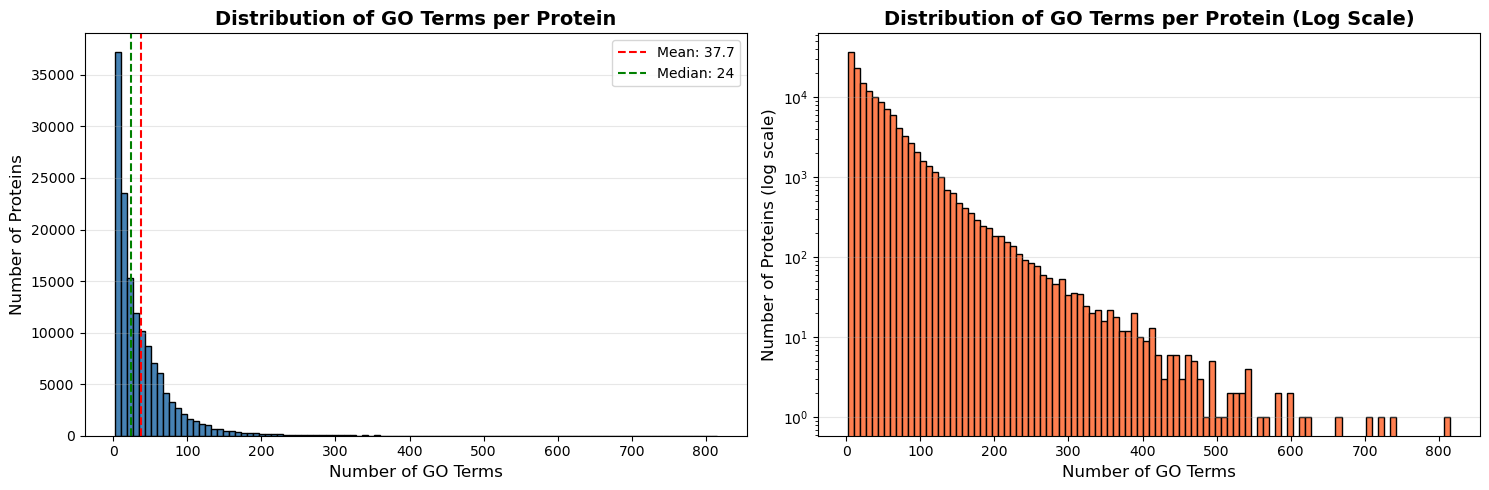


✓ Saved: visuals/02_go_terms_per_protein.png


In [7]:
# Cell 5: Proteins Per GO Term Distribution
print("\n" + "="*70)
print("NUMBER OF GO TERMS PER PROTEIN")
print("="*70)

# Count GO terms per protein
protein_go_counts = train_terms.groupby('EntryID').agg({
    'term': 'count',
    'aspect': lambda x: x.value_counts().to_dict()
}).reset_index()
protein_go_counts.columns = ['EntryID', 'total_GO_terms', 'aspect_breakdown']

print(f"\n📊 GO TERMS PER PROTEIN STATISTICS:")
print(protein_go_counts['total_GO_terms'].describe())

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Linear scale
axes[0].hist(protein_go_counts['total_GO_terms'], bins=100, 
            color='steelblue', edgecolor='black')
axes[0].set_xlabel('Number of GO Terms', fontsize=12)
axes[0].set_ylabel('Number of Proteins', fontsize=12)
axes[0].set_title('Distribution of GO Terms per Protein', fontsize=14, fontweight='bold')
axes[0].axvline(protein_go_counts['total_GO_terms'].mean(), color='red', 
               linestyle='--', label=f'Mean: {protein_go_counts["total_GO_terms"].mean():.1f}')
axes[0].axvline(protein_go_counts['total_GO_terms'].median(), color='green',
               linestyle='--', label=f'Median: {protein_go_counts["total_GO_terms"].median():.0f}')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Log scale
axes[1].hist(protein_go_counts['total_GO_terms'], bins=100,
            color='coral', edgecolor='black')
axes[1].set_xlabel('Number of GO Terms', fontsize=12)
axes[1].set_ylabel('Number of Proteins (log scale)', fontsize=12)
axes[1].set_title('Distribution of GO Terms per Protein (Log Scale)', 
                 fontsize=14, fontweight='bold')
axes[1].set_yscale('log')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/visuals/02_go_terms_per_protein.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: visuals/02_go_terms_per_protein.png")

In [9]:
# Cell 6: Load Protein Sequences

import os
from Bio import SeqIO
import pandas as pd
from tqdm import tqdm

print("\n" + "="*70)
print("LOADING PROTEIN SEQUENCES")
print("="*70)

fasta_file = r"C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/data/raw/train_sequences.fasta"

sequences_data = []

print("\nParsing sequences...")

with open(fasta_file, "r") as handle:
    for record in tqdm(SeqIO.parse(handle, "fasta")):
        sequences_data.append({
            "EntryID": record.id,
            "description": record.description,
            "sequence": str(record.seq),
            "length": len(record.seq)
        })

sequences_df = pd.DataFrame(sequences_data)

print(f"\n✓ Parsed {len(sequences_df):,} sequences")

print("\nFirst 5 sequences:")
print(sequences_df.head())

print("\n📊 SEQUENCE LENGTH STATISTICS:")
print(sequences_df["length"].describe())



LOADING PROTEIN SEQUENCES

Parsing sequences...


142246it [00:03, 40480.72it/s]



✓ Parsed 142,246 sequences

First 5 sequences:
      EntryID                                        description  \
0      P20536  P20536 sp|P20536|UNG_VACCC Uracil-DNA glycosyl...   
1      O73864  O73864 sp|O73864|WNT11_DANRE Protein Wnt-11 OS...   
2      O95231  O95231 sp|O95231|VENTX_HUMAN Homeobox protein ...   
3  A0A0B4J1F4  A0A0B4J1F4 sp|A0A0B4J1F4|ARRD4_MOUSE Arrestin ...   
4      P54366  P54366 sp|P54366|GSC_DROME Homeobox protein go...   

                                            sequence  length  
0  MNSVTVSHAPYTITYHDDWEPVMSQLVEFYNEVASWLLRDETSPIP...     218  
1  MTEYRNFLLLFITSLSVIYPCTGISWLGLTINGSSVGWNQTHHCKL...     354  
2  MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...     258  
3  MGGEAGADGPRGRVKSLGLVFEDESKGCYSSGETVAGHVLLEAAEP...     415  
4  MVETNSPPAGYTLKRSPSDLGEQQQPPRQISRSPGNTAAYHLTTAM...     415  

📊 SEQUENCE LENGTH STATISTICS:
count    142246.000000
mean        553.636679
std         641.728770
min           3.000000
25%         248.000000
50%         411.000

In [10]:
# Cell 7: Parse ALL Training Sequences

import pandas as pd
from Bio import SeqIO
from tqdm import tqdm
import os

print("\n" + "="*70)
print("PARSING ALL TRAINING SEQUENCES")
print("="*70)

fasta_file = r"C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/data/raw/train_sequences.fasta"

all_sequences = []

print("\nProcessing FASTA file...")

with open(fasta_file, "r") as handle:
    for record in tqdm(SeqIO.parse(handle, "fasta")):
        all_sequences.append({
            "EntryID": record.id,
            "description": record.description,
            "sequence": str(record.seq),
            "length": len(record.seq)
        })

all_sequences_df = pd.DataFrame(all_sequences)

print(f"\n✓ Total sequences parsed: {len(all_sequences_df):,}")

# Ensure processed folder exists
os.makedirs("../data/processed", exist_ok=True)

# Save
all_sequences_df.to_csv("C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/data/processed/train_sequences.csv", index=False)

print("\n✓ Saved: data/processed/train_sequences.csv")

print("\n📊 FULL DATASET SEQUENCE STATISTICS:")
print(all_sequences_df["length"].describe())



PARSING ALL TRAINING SEQUENCES

Processing FASTA file...


142246it [00:03, 38945.88it/s]



✓ Total sequences parsed: 142,246

✓ Saved: data/processed/train_sequences.csv

📊 FULL DATASET SEQUENCE STATISTICS:
count    142246.000000
mean        553.636679
std         641.728770
min           3.000000
25%         248.000000
50%         411.000000
75%         654.000000
max       35375.000000
Name: length, dtype: float64


In [18]:
# Cell 8: Merge Sequences with Annotations (Corrected for CAFA5)
print("\n" + "="*70)
print("MERGING SEQUENCES AND ANNOTATIONS")
print("="*70)

# Merge sequences with GO terms for overview (optional)
merged_data = all_sequences_df.merge(
    train_terms[['EntryID', 'term', 'aspect']], 
    on='EntryID', 
    how='inner'
)
print(f"\n✓ Merged data (for overview): {len(merged_data):,} rows")

# Create protein-level dataset
protein_data = all_sequences_df.copy()

# Correct aspect mapping for CAFA5
aspect_map = [
    ('MFO', 'MF'),  # Molecular Function
    ('BPO', 'BP'),  # Biological Process
    ('CCO', 'CC')   # Cellular Component
]

for aspect, aspect_name in aspect_map:
    # Group GO terms by protein
    aspect_terms = (
        train_terms[train_terms['aspect'] == aspect]
        .groupby('EntryID')['term']
        .apply(list)
        .to_dict()
    )
    
    # Map GO terms to protein_data
    protein_data[f'GO_{aspect_name}'] = protein_data['EntryID'].map(aspect_terms)
    # Replace NaN with empty list
    protein_data[f'GO_{aspect_name}'] = protein_data[f'GO_{aspect_name}'].apply(lambda x: x if isinstance(x, list) else [])
    # Count number of GO terms
    protein_data[f'num_GO_{aspect_name}'] = protein_data[f'GO_{aspect_name}'].apply(len)

# Total GO terms per protein
protein_data['total_GO_terms'] = (
    protein_data['num_GO_MF'] +
    protein_data['num_GO_BP'] +
    protein_data['num_GO_CC']
)

print(f"\n✓ Created protein-level dataset")
print(f"  Proteins with annotations: {(protein_data['total_GO_terms'] > 0).sum():,}")

print(f"\nFirst 5 proteins:")
print(protein_data[['EntryID', 'length', 'num_GO_MF', 'num_GO_BP', 'num_GO_CC', 'total_GO_terms']].head())

# Ensure processed directory exists
import os
os.makedirs('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/data/processed', exist_ok=True)

# Save the dataset with UTF-8 encoding
protein_data.to_csv(
    'C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/data/processed/protein_dataset_with_go.csv',
    index=False,
    encoding='utf-8'
)
print("\n✓ Saved: data/processed/protein_dataset_with_go.csv")


MERGING SEQUENCES AND ANNOTATIONS

✓ Merged data (for overview): 5,363,863 rows

✓ Created protein-level dataset
  Proteins with annotations: 142,246

First 5 proteins:
      EntryID  length  num_GO_MF  num_GO_BP  num_GO_CC  total_GO_terms
0      P20536     218          3         30          0              33
1      O73864     354          5        160          5             170
2      O95231     258         15         34         13              62
3  A0A0B4J1F4     415          5         28         12              45
4      P54366     415         12          0          8              20

✓ Saved: data/processed/protein_dataset_with_go.csv



SEQUENCE LENGTH ANALYSIS


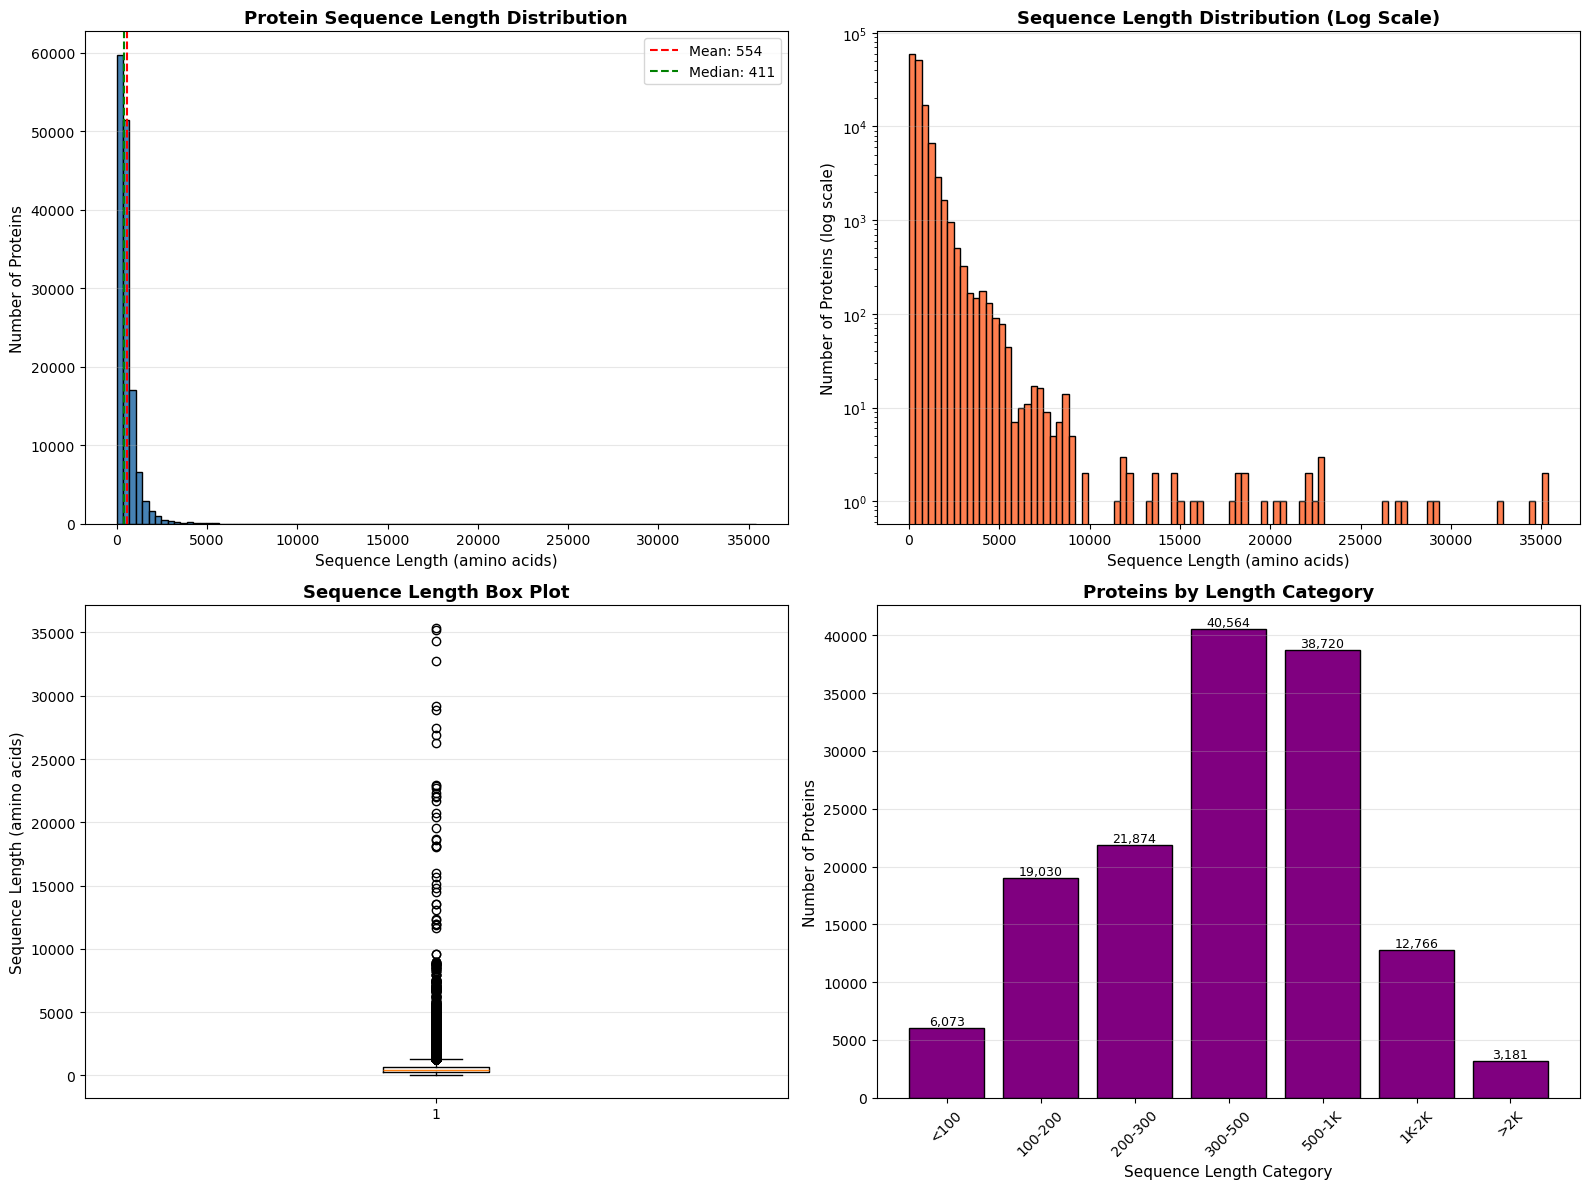


✓ Saved: visuals/03_sequence_length_analysis.png


In [19]:
# Cell 9: Sequence Length Distribution
print("\n" + "="*70)
print("SEQUENCE LENGTH ANALYSIS")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Overall distribution
axes[0, 0].hist(protein_data['length'], bins=100, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Sequence Length (amino acids)', fontsize=11)
axes[0, 0].set_ylabel('Number of Proteins', fontsize=11)
axes[0, 0].set_title('Protein Sequence Length Distribution', fontsize=13, fontweight='bold')
axes[0, 0].axvline(protein_data['length'].mean(), color='red', linestyle='--',
                  label=f'Mean: {protein_data["length"].mean():.0f}')
axes[0, 0].axvline(protein_data['length'].median(), color='green', linestyle='--',
                  label=f'Median: {protein_data["length"].median():.0f}')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Log scale
axes[0, 1].hist(protein_data['length'], bins=100, color='coral', edgecolor='black')
axes[0, 1].set_xlabel('Sequence Length (amino acids)', fontsize=11)
axes[0, 1].set_ylabel('Number of Proteins (log scale)', fontsize=11)
axes[0, 1].set_title('Sequence Length Distribution (Log Scale)', fontsize=13, fontweight='bold')
axes[0, 1].set_yscale('log')
axes[0, 1].grid(axis='y', alpha=0.3)

# Box plot
axes[1, 0].boxplot(protein_data['length'], vert=True)
axes[1, 0].set_ylabel('Sequence Length (amino acids)', fontsize=11)
axes[1, 0].set_title('Sequence Length Box Plot', fontsize=13, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# Length categories
length_bins = [0, 100, 200, 300, 500, 1000, 2000, 10000]
length_labels = ['<100', '100-200', '200-300', '300-500', '500-1K', '1K-2K', '>2K']
protein_data['length_category'] = pd.cut(protein_data['length'], bins=length_bins, labels=length_labels)

category_counts = protein_data['length_category'].value_counts().sort_index()
axes[1, 1].bar(range(len(category_counts)), category_counts.values, 
              color='purple', edgecolor='black')
axes[1, 1].set_xticks(range(len(category_counts)))
axes[1, 1].set_xticklabels(category_counts.index, rotation=45)
axes[1, 1].set_xlabel('Sequence Length Category', fontsize=11)
axes[1, 1].set_ylabel('Number of Proteins', fontsize=11)
axes[1, 1].set_title('Proteins by Length Category', fontsize=13, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

for i, v in enumerate(category_counts.values):
    axes[1, 1].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/visuals/03_sequence_length_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: visuals/03_sequence_length_analysis.png")


AMINO ACID COMPOSITION ANALYSIS


Analyzing amino acids: 100%|██████████| 10000/10000 [00:00<00:00, 13404.14it/s]



📊 AMINO ACID FREQUENCIES (Top 20):
  L: 9.378%
  S: 8.225%
  A: 7.046%
  E: 6.942%
  G: 6.386%
  V: 6.260%
  K: 5.863%
  T: 5.559%
  P: 5.555%
  R: 5.412%
  D: 5.278%
  I: 4.925%
  Q: 4.571%
  N: 4.341%
  F: 3.711%
  Y: 2.855%
  H: 2.453%
  M: 2.259%
  C: 1.860%
  W: 1.118%


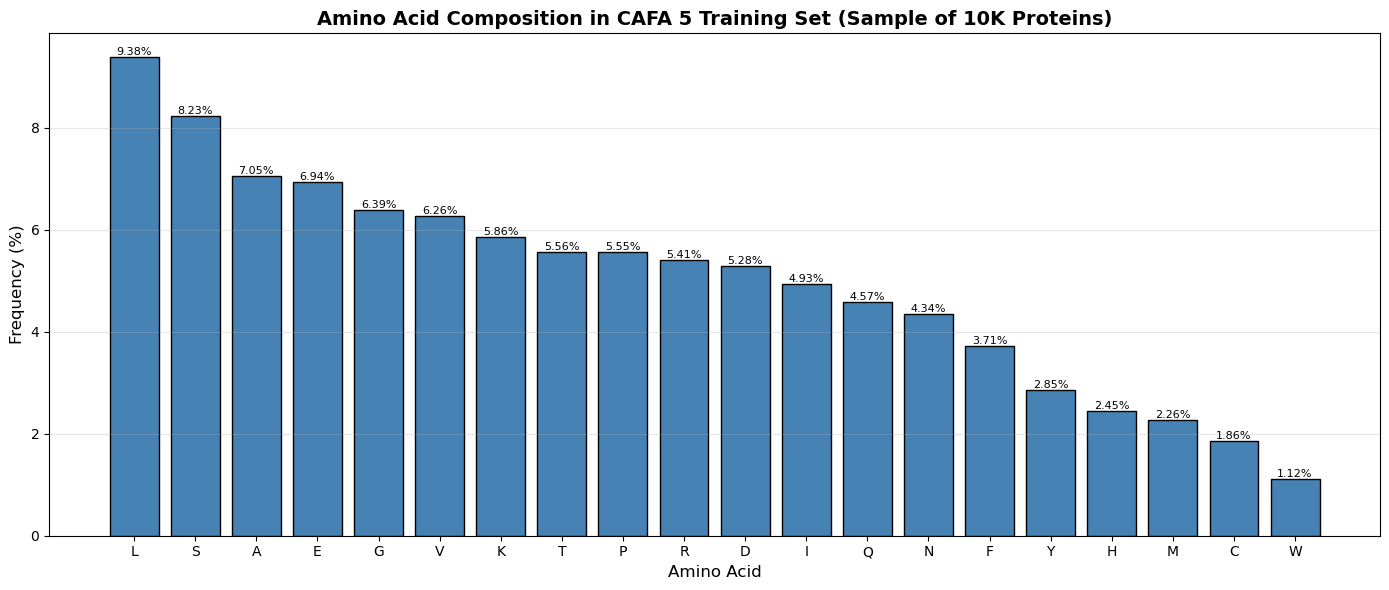


✓ Saved: visuals/04_amino_acid_composition.png


In [13]:
# Cell 10: Amino Acid Composition
print("\n" + "="*70)
print("AMINO ACID COMPOSITION ANALYSIS")
print("="*70)

# Sample 10,000 sequences for speed
sample_sequences = protein_data['sequence'].sample(min(10000, len(protein_data)), random_state=42)

aa_counts = Counter()
for seq in tqdm(sample_sequences, desc="Analyzing amino acids"):
    aa_counts.update(seq)

# Calculate percentages
total_aa = sum(aa_counts.values())
aa_percentages = {aa: (count/total_aa)*100 for aa, count in aa_counts.items()}

# Sort by frequency
aa_sorted = sorted(aa_percentages.items(), key=lambda x: x[1], reverse=True)

# Filter only standard amino acids
standard_aas = set('ACDEFGHIKLMNPQRSTVWY')
aa_sorted = [(aa, pct) for aa, pct in aa_sorted if aa in standard_aas]

print("\n📊 AMINO ACID FREQUENCIES (Top 20):")
for aa, pct in aa_sorted:
    print(f"  {aa}: {pct:.3f}%")

# Visualize
aa_names = [aa for aa, _ in aa_sorted]
aa_pcts = [pct for _, pct in aa_sorted]

plt.figure(figsize=(14, 6))
plt.bar(aa_names, aa_pcts, color='steelblue', edgecolor='black')
plt.xlabel('Amino Acid', fontsize=12)
plt.ylabel('Frequency (%)', fontsize=12)
plt.title('Amino Acid Composition in CAFA 5 Training Set (Sample of 10K Proteins)',
         fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

for i, (aa, pct) in enumerate(zip(aa_names, aa_pcts)):
    plt.text(i, pct, f'{pct:.2f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/visuals/04_amino_acid_composition.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: visuals/04_amino_acid_composition.png")

In [20]:
# Cell 11: Data Summary Report
print("\n" + "="*70)
print("CAFA 5 DATASET SUMMARY")
print("="*70)

summary = f"""
CAFA 5 PROTEIN FUNCTION PREDICTION - DATA EXPLORATION SUMMARY

DATASET SOURCE:
- Competition: CAFA 5 (Critical Assessment of Functional Annotation)
- Platform: Kaggle
- URL: https://www.kaggle.com/c/cafa-5-protein-function-prediction

TRAINING DATA STATISTICS:
- Total proteins: {len(protein_data):,}
- Total protein-GO term pairs: {len(train_terms):,}
- Unique GO terms: {train_terms['term'].nunique():,}
  • Molecular Function (F): {len(train_terms[train_terms['aspect'] == 'F']['term'].unique()):,}
  • Biological Process (P): {len(train_terms[train_terms['aspect'] == 'P']['term'].unique()):,}
  • Cellular Component (C): {len(train_terms[train_terms['aspect'] == 'C']['term'].unique()):,}

SEQUENCE STATISTICS:
- Mean length: {protein_data['length'].mean():.0f} amino acids
- Median length: {protein_data['length'].median():.0f} amino acids
- Min length: {protein_data['length'].min()}
- Max length: {protein_data['length'].max()}
- Std dev: {protein_data['length'].std():.0f}

GO TERM ANNOTATIONS PER PROTEIN:
- Mean total GO terms: {protein_data['total_GO_terms'].mean():.2f}
- Median total GO terms: {protein_data['total_GO_terms'].median():.0f}
- Mean MF terms: {protein_data['num_GO_MF'].mean():.2f}
- Mean BP terms: {protein_data['num_GO_BP'].mean():.2f}
- Mean CC terms: {protein_data['num_GO_CC'].mean():.2f}

TOP 5 MOST COMMON GO TERMS (OVERALL):
"""

top_5_overall = go_term_counts.head(5)
for idx, row in top_5_overall.iterrows():
    summary += f"\n  {row['term']} ({row['aspect']}): {row['protein_count']:,} proteins"

summary += f"""

DATA QUALITY:
- Proteins with at least one GO term: {(protein_data['total_GO_terms'] > 0).sum():,} ({(protein_data['total_GO_terms'] > 0).sum()/len(protein_data)*100:.1f}%)
- Complete sequences: ✓
- Missing values: None detected

DATASET CHARACTERISTICS:
- Multi-label classification problem
- Hierarchical labels (GO term structure)
- Imbalanced labels (some GO terms are rare)
- Variable sequence lengths (need padding/truncation)
- Large vocabulary (20 amino acids + special tokens)

CHALLENGES IDENTIFIED:
1. Label imbalance - top GO terms have 1000s of examples, rare ones have <10
2. Long sequences - some proteins >5000 amino acids (computational cost)
3. Hierarchical structure - GO terms have parent-child relationships
4. Multi-label - each protein has multiple GO terms

NEXT STEPS:
1. Select target GO terms (focus on common terms initially)
2. Feature extraction (amino acid composition, k-mers, embeddings)
3. Baseline models (classical ML)
4. Deep learning (LSTM, CNN, Transformers)
5. Evaluation using CAFA metrics (Fmax, AUPR, Smin)

FILES GENERATED:
- data/processed/train_sequences.csv
- data/processed/protein_dataset_with_go.csv
- data/processed/GO_F_frequencies.csv
- data/processed/GO_P_frequencies.csv
- data/processed/GO_C_frequencies.csv
- visuals/01_top_go_terms_by_category.png
- visuals/02_go_terms_per_protein.png
- visuals/03_sequence_length_analysis.png
- visuals/04_amino_acid_composition.png
"""

print(summary)

# Save summary with UTF-8 encoding
with open(
    'C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/reports/01_data_exploration_summary.txt', 
    'w', encoding='utf-8'
) as f:
    f.write(summary)

print("\n" + "="*70)
print("✓ Saved: reports/01_data_exploration_summary.txt")


CAFA 5 DATASET SUMMARY

CAFA 5 PROTEIN FUNCTION PREDICTION - DATA EXPLORATION SUMMARY

DATASET SOURCE:
- Competition: CAFA 5 (Critical Assessment of Functional Annotation)
- Platform: Kaggle
- URL: https://www.kaggle.com/c/cafa-5-protein-function-prediction

TRAINING DATA STATISTICS:
- Total proteins: 142,246
- Total protein-GO term pairs: 5,363,863
- Unique GO terms: 31,466
  • Molecular Function (F): 0
  • Biological Process (P): 0
  • Cellular Component (C): 0

SEQUENCE STATISTICS:
- Mean length: 554 amino acids
- Median length: 411 amino acids
- Min length: 3
- Max length: 35375
- Std dev: 642

GO TERM ANNOTATIONS PER PROTEIN:
- Mean total GO terms: 37.71
- Median total GO terms: 24
- Mean MF terms: 4.71
- Mean BP terms: 24.59
- Mean CC terms: 8.41

TOP 5 MOST COMMON GO TERMS (OVERALL):

  GO:0005575 (CCO): 92,912 proteins
  GO:0008150 (BPO): 92,210 proteins
  GO:0110165 (CCO): 91,286 proteins
  GO:0003674 (MFO): 78,637 proteins
  GO:0005622 (CCO): 70,785 proteins

DATA QUALITY:
-

In [21]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm import tqdm
import pickle
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("FEATURE EXTRACTION FOR PROTEIN SEQUENCES")
print("="*70)

FEATURE EXTRACTION FOR PROTEIN SEQUENCES


In [22]:
# Cell 2: Load Processed Data
print("\n" + "="*70)
print("LOADING DATA")
print("="*70)

# Load protein dataset
protein_df = pd.read_csv('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/data/processed/protein_dataset_with_go.csv')

print(f"✓ Loaded {len(protein_df):,} proteins")
print(f"\nFirst 5 rows:")
print(protein_df[['EntryID', 'length', 'num_GO_MF', 'num_GO_BP', 'num_GO_CC']].head())


LOADING DATA
✓ Loaded 142,246 proteins

First 5 rows:
      EntryID  length  num_GO_MF  num_GO_BP  num_GO_CC
0      P20536     218          3         30          0
1      O73864     354          5        160          5
2      O95231     258         15         34         13
3  A0A0B4J1F4     415          5         28         12
4      P54366     415         12          0          8


In [25]:
protein_df[['EntryID','GO_MF','GO_BP','GO_CC']].head(5)

,EntryID,GO_MF,GO_BP,GO_CC
0,P20536,"['GO:0005515', 'GO:0005488', 'GO:0003674']","['GO:0008152', 'GO:0071897', 'GO:0044249', 'GO...",[]
1,O73864,"['GO:0046982', 'GO:0003674', 'GO:0005488', 'GO...","['GO:0061371', 'GO:0048589', 'GO:0051641', 'GO...","['GO:0071944', 'GO:0005575', 'GO:0110165', 'GO..."
2,O95231,"['GO:0003676', 'GO:1990837', 'GO:0001216', 'GO...","['GO:0006357', 'GO:0010557', 'GO:0045935', 'GO...","['GO:0005622', 'GO:0031981', 'GO:0043229', 'GO..."
3,A0A0B4J1F4,"['GO:0030674', 'GO:0003674', 'GO:1990756', 'GO...","['GO:0008152', 'GO:0051234', 'GO:0036211', 'GO...","['GO:0065010', 'GO:0043226', 'GO:1903561', 'GO..."
4,P54366,"['GO:0001227', 'GO:0042803', 'GO:0042802', 'GO...",[],"['GO:0005622', 'GO:0043229', 'GO:0043226', 'GO..."


In [26]:
# Cell 3: Amino Acid Composition (AAC) Features
print("\n" + "="*70)
print("FEATURE 1: AMINO ACID COMPOSITION (AAC)")
print("="*70)

def calculate_aac(sequence):
    """
    Calculate amino acid composition - percentage of each amino acid
    Returns 20-dimensional feature vector
    """
    amino_acids = 'ACDEFGHIKLMNPQRSTVWY'
    aac = {}
    
    seq_length = len(sequence)
    if seq_length == 0:
        return {aa: 0.0 for aa in amino_acids}
    
    # Count each amino acid
    aa_counts = Counter(sequence)
    
    # Calculate percentages
    for aa in amino_acids:
        aac[aa] = (aa_counts.get(aa, 0) / seq_length) * 100
    
    return aac

# Test on sample
sample_sequence = protein_df.iloc[0]['sequence']
sample_aac = calculate_aac(sample_sequence)

print(f"\nSample sequence: {sample_sequence[:50]}...")
print(f"Length: {len(sample_sequence)}")
print(f"\nAmino Acid Composition:")
for aa, pct in sorted(sample_aac.items()):
    print(f"  {aa}: {pct:.2f}%")

# Extract AAC features for all proteins
print(f"\nExtracting AAC features for all {len(protein_df):,} proteins...")

aac_features = []
for sequence in tqdm(protein_df['sequence'], desc="AAC extraction"):
    aac = calculate_aac(sequence)
    aac_features.append(aac)

# Convert to DataFrame
aac_df = pd.DataFrame(aac_features)
aac_df.columns = [f'AAC_{aa}' for aa in aac_df.columns]

print(f"\n✓ AAC features extracted")
print(f"  Shape: {aac_df.shape}")
print(f"  Features: {aac_df.columns.tolist()}")


FEATURE 1: AMINO ACID COMPOSITION (AAC)

Sample sequence: MNSVTVSHAPYTITYHDDWEPVMSQLVEFYNEVASWLLRDETSPIPDKFF...
Length: 218

Amino Acid Composition:
  A: 3.67%
  C: 1.83%
  D: 5.96%
  E: 5.05%
  F: 4.13%
  G: 4.59%
  H: 2.75%
  I: 9.17%
  K: 7.80%
  L: 8.26%
  M: 0.92%
  N: 5.05%
  P: 5.96%
  Q: 2.75%
  R: 3.67%
  S: 7.80%
  T: 5.50%
  V: 7.34%
  W: 2.29%
  Y: 5.50%

Extracting AAC features for all 142,246 proteins...


AAC extraction: 100%|██████████| 142246/142246 [00:12<00:00, 11584.59it/s]



✓ AAC features extracted
  Shape: (142246, 20)
  Features: ['AAC_A', 'AAC_C', 'AAC_D', 'AAC_E', 'AAC_F', 'AAC_G', 'AAC_H', 'AAC_I', 'AAC_K', 'AAC_L', 'AAC_M', 'AAC_N', 'AAC_P', 'AAC_Q', 'AAC_R', 'AAC_S', 'AAC_T', 'AAC_V', 'AAC_W', 'AAC_Y']


In [28]:
# Cell 4: Dipeptide Composition (DPC) Features
print("\n" + "="*70)
print("FEATURE 2: DIPEPTIDE COMPOSITION (DPC)")
print("="*70)

def calculate_dpc(sequence):
    """
    Calculate dipeptide composition - frequency of amino acid pairs
    Returns 400-dimensional feature vector (20 x 20)
    """
    amino_acids = 'ACDEFGHIKLMNPQRSTVWY'
    
    # Generate all possible dipeptides
    dipeptides = [aa1 + aa2 for aa1 in amino_acids for aa2 in amino_acids]
    
    dpc = {dipep: 0.0 for dipep in dipeptides}
    
    # Count dipeptides in sequence
    total_dipeptides = len(sequence) - 1
    if total_dipeptides <= 0:
        return dpc
    
    for i in range(total_dipeptides):
        dipep = sequence[i:i+2]
        if len(dipep) == 2 and dipep in dpc:
            dpc[dipep] += 1
    
    # Convert to percentages
    for dipep in dpc:
        dpc[dipep] = (dpc[dipep] / total_dipeptides) * 100
    
    return dpc

# Test on sample
sample_dpc = calculate_dpc(sample_sequence)
print(f"\nSample Dipeptide Composition (top 20):")
sorted_dpc = sorted(sample_dpc.items(), key=lambda x: x[1], reverse=True)[:20]
for dipep, pct in sorted_dpc:
    if pct > 0:
        print(f"  {dipep}: {pct:.2f}%")

# Extract DPC for subset (DPC is expensive - 400 features)
# Use first 5000 proteins for demo
sample_size = min(5000, len(protein_df))
print(f"\nExtracting DPC features for {sample_size} proteins (sample)...")

dpc_features = []
for sequence in tqdm(protein_df['sequence'].head(sample_size), desc="DPC extraction"):
    dpc = calculate_dpc(sequence)
    dpc_features.append(dpc)

dpc_df = pd.DataFrame(dpc_features)
dpc_df.columns = [f'DPC_{col}' for col in dpc_df.columns]

print(f"\n✓ DPC features extracted")
print(f"  Shape: {dpc_df.shape}")
print(f"  Note: Using sample of {sample_size} proteins for computational efficiency")


FEATURE 2: DIPEPTIDE COMPOSITION (DPC)

Sample Dipeptide Composition (top 20):
  LL: 1.84%
  FE: 1.38%
  GV: 1.38%
  ID: 1.38%
  KL: 1.38%
  SP: 1.38%
  TK: 1.38%
  AS: 0.92%
  DG: 0.92%
  DK: 0.92%
  DR: 0.92%
  EI: 0.92%
  ES: 0.92%
  ET: 0.92%
  FI: 0.92%
  GY: 0.92%
  HA: 0.92%
  II: 0.92%
  IN: 0.92%
  IP: 0.92%

Extracting DPC features for 5000 proteins (sample)...


DPC extraction: 100%|██████████| 5000/5000 [00:03<00:00, 1295.91it/s]



✓ DPC features extracted
  Shape: (5000, 400)
  Note: Using sample of 5000 proteins for computational efficiency


In [29]:
# Cell 5: Physicochemical Properties
print("\n" + "="*70)
print("FEATURE 3: PHYSICOCHEMICAL PROPERTIES")
print("="*70)

# Amino acid properties
aa_properties = {
    # Hydrophobicity (Kyte-Doolittle scale)
    'hydrophobicity': {
        'A': 1.8, 'C': 2.5, 'D': -3.5, 'E': -3.5, 'F': 2.8,
        'G': -0.4, 'H': -3.2, 'I': 4.5, 'K': -3.9, 'L': 3.8,
        'M': 1.9, 'N': -3.5, 'P': -1.6, 'Q': -3.5, 'R': -4.5,
        'S': -0.8, 'T': -0.7, 'V': 4.2, 'W': -0.9, 'Y': -1.3
    },
    # Molecular weight
    'molecular_weight': {
        'A': 89.09, 'C': 121.16, 'D': 133.10, 'E': 147.13, 'F': 165.19,
        'G': 75.07, 'H': 155.16, 'I': 131.18, 'K': 146.19, 'L': 131.18,
        'M': 149.21, 'N': 132.12, 'P': 115.13, 'Q': 146.15, 'R': 174.20,
        'S': 105.09, 'T': 119.12, 'V': 117.15, 'W': 204.23, 'Y': 181.19
    },
    # Charge at pH 7
    'charge': {
        'A': 0, 'C': 0, 'D': -1, 'E': -1, 'F': 0,
        'G': 0, 'H': 0, 'I': 0, 'K': 1, 'L': 0,
        'M': 0, 'N': 0, 'P': 0, 'Q': 0, 'R': 1,
        'S': 0, 'T': 0, 'V': 0, 'W': 0, 'Y': 0
    },
    # Polarity
    'polarity': {
        'A': 0, 'C': 1, 'D': 1, 'E': 1, 'F': 0,
        'G': 0, 'H': 1, 'I': 0, 'K': 1, 'L': 0,
        'M': 0, 'N': 1, 'P': 0, 'Q': 1, 'R': 1,
        'S': 1, 'T': 1, 'V': 0, 'W': 0, 'Y': 1
    }
}

def calculate_physicochemical_features(sequence):
    """
    Calculate aggregate physicochemical properties
    Returns mean, std, min, max for each property
    """
    features = {}
    
    for prop_name, prop_dict in aa_properties.items():
        values = [prop_dict.get(aa, 0) for aa in sequence]
        
        if len(values) > 0:
            features[f'{prop_name}_mean'] = np.mean(values)
            features[f'{prop_name}_std'] = np.std(values)
            features[f'{prop_name}_min'] = np.min(values)
            features[f'{prop_name}_max'] = np.max(values)
        else:
            features[f'{prop_name}_mean'] = 0
            features[f'{prop_name}_std'] = 0
            features[f'{prop_name}_min'] = 0
            features[f'{prop_name}_max'] = 0
    
    return features

# Test
sample_physchem = calculate_physicochemical_features(sample_sequence)
print("\nSample Physicochemical Features:")
for feat, val in sample_physchem.items():
    print(f"  {feat}: {val:.4f}")

# Extract for all proteins
print(f"\nExtracting physicochemical features for all proteins...")

physchem_features = []
for sequence in tqdm(protein_df['sequence'], desc="Physicochemical extraction"):
    physchem = calculate_physicochemical_features(sequence)
    physchem_features.append(physchem)

physchem_df = pd.DataFrame(physchem_features)

print(f"\n✓ Physicochemical features extracted")
print(f"  Shape: {physchem_df.shape}")
print(f"  Features: {physchem_df.columns.tolist()}")


FEATURE 3: PHYSICOCHEMICAL PROPERTIES

Sample Physicochemical Features:
  hydrophobicity_mean: -0.2427
  hydrophobicity_std: 3.1208
  hydrophobicity_min: -4.5000
  hydrophobicity_max: 4.5000
  molecular_weight_mean: 132.9783
  molecular_weight_std: 27.0243
  molecular_weight_min: 75.0700
  molecular_weight_max: 204.2300
  charge_mean: 0.0046
  charge_std: 0.4741
  charge_min: -1.0000
  charge_max: 1.0000
  polarity_mean: 0.5367
  polarity_std: 0.4987
  polarity_min: 0.0000
  polarity_max: 1.0000

Extracting physicochemical features for all proteins...


Physicochemical extraction: 100%|██████████| 142246/142246 [03:21<00:00, 704.33it/s] 



✓ Physicochemical features extracted
  Shape: (142246, 16)
  Features: ['hydrophobicity_mean', 'hydrophobicity_std', 'hydrophobicity_min', 'hydrophobicity_max', 'molecular_weight_mean', 'molecular_weight_std', 'molecular_weight_min', 'molecular_weight_max', 'charge_mean', 'charge_std', 'charge_min', 'charge_max', 'polarity_mean', 'polarity_std', 'polarity_min', 'polarity_max']


In [30]:
# Cell 6: K-mer Features (3-mers)
print("\n" + "="*70)
print("FEATURE 4: K-MER FEATURES (3-mers)")
print("="*70)

def calculate_kmer_features(sequence, k=3, top_n=100):
    """
    Calculate k-mer frequencies
    Returns top_n most common k-mers
    """
    kmers = {}
    
    # Extract all k-mers
    for i in range(len(sequence) - k + 1):
        kmer = sequence[i:i+k]
        if len(kmer) == k:
            kmers[kmer] = kmers.get(kmer, 0) + 1
    
    # Convert to frequencies
    total_kmers = sum(kmers.values())
    if total_kmers > 0:
        kmers = {kmer: (count/total_kmers)*100 for kmer, count in kmers.items()}
    
    return kmers

# Get most common k-mers across all sequences (sample)
print("\nFinding most common 3-mers across dataset...")

all_kmers = Counter()
for sequence in tqdm(protein_df['sequence'].head(1000), desc="Counting k-mers"):
    kmers = calculate_kmer_features(sequence, k=3, top_n=None)
    all_kmers.update(kmers.keys())

# Get top 100 most common k-mers
top_kmers = [kmer for kmer, _ in all_kmers.most_common(100)]

print(f"\nTop 20 most common 3-mers:")
for i, (kmer, count) in enumerate(all_kmers.most_common(20), 1):
    print(f"  {i:2d}. {kmer}: appears in {count} sequences")

# Extract k-mer features for all proteins (using top 100)
print(f"\nExtracting 3-mer features for all proteins...")

kmer_features = []
for sequence in tqdm(protein_df['sequence'], desc="K-mer extraction"):
    kmers = calculate_kmer_features(sequence, k=3)
    
    # Create feature vector with top k-mers
    kmer_vector = {f'3mer_{kmer}': kmers.get(kmer, 0.0) for kmer in top_kmers}
    kmer_features.append(kmer_vector)

kmer_df = pd.DataFrame(kmer_features)

print(f"\n✓ K-mer features extracted")
print(f"  Shape: {kmer_df.shape}")


FEATURE 4: K-MER FEATURES (3-mers)

Finding most common 3-mers across dataset...


Counting k-mers: 100%|██████████| 1000/1000 [00:00<00:00, 2114.56it/s]



Top 20 most common 3-mers:
   1. SSS: appears in 316 sequences
   2. LLL: appears in 306 sequences
   3. SSL: appears in 293 sequences
   4. LLS: appears in 291 sequences
   5. LLA: appears in 289 sequences
   6. ALL: appears in 284 sequences
   7. SLL: appears in 279 sequences
   8. LLE: appears in 273 sequences
   9. LSS: appears in 270 sequences
  10. LSL: appears in 270 sequences
  11. LAL: appears in 268 sequences
  12. ELL: appears in 264 sequences
  13. LAA: appears in 263 sequences
  14. EEE: appears in 261 sequences
  15. SLS: appears in 260 sequences
  16. EEL: appears in 258 sequences
  17. LGL: appears in 255 sequences
  18. LLG: appears in 249 sequences
  19. LEE: appears in 246 sequences
  20. LVL: appears in 242 sequences

Extracting 3-mer features for all proteins...


K-mer extraction: 100%|██████████| 142246/142246 [00:57<00:00, 2490.39it/s]



✓ K-mer features extracted
  Shape: (142246, 100)


In [31]:
# Cell 7: Combine All Features
print("\n" + "="*70)
print("COMBINING ALL FEATURES")
print("="*70)

# Combine all feature sets
print("\nCombining feature sets...")

# Start with AAC (all proteins)
combined_features = aac_df.copy()

# Add physicochemical
combined_features = pd.concat([combined_features, physchem_df], axis=1)

# Add k-mers
combined_features = pd.concat([combined_features, kmer_df], axis=1)

# Add sequence length
combined_features['sequence_length'] = protein_df['length'].values

# Add protein ID
combined_features['EntryID'] = protein_df['EntryID'].values

print(f"\n✓ Combined features created")
print(f"  Shape: {combined_features.shape}")
print(f"  Total features: {combined_features.shape[1] - 1}")  # -1 for EntryID

print(f"\nFeature breakdown:")
print(f"  AAC features: 20")
print(f"  Physicochemical features: {physchem_df.shape[1]}")
print(f"  K-mer features: {kmer_df.shape[1]}")
print(f"  Sequence length: 1")
print(f"  Total: {combined_features.shape[1] - 1}")

# Display sample
print(f"\nFirst 5 rows (sample columns):")
print(combined_features[['EntryID', 'AAC_A', 'AAC_C', 'hydrophobicity_mean', 
                         'sequence_length']].head())

# Save features
combined_features.to_csv('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/data/features/protein_features_all.csv', index=False)
print("\n✓ Saved: data/features/protein_features_all.csv")


COMBINING ALL FEATURES

Combining feature sets...

✓ Combined features created
  Shape: (142246, 138)
  Total features: 137

Feature breakdown:
  AAC features: 20
  Physicochemical features: 16
  K-mer features: 100
  Sequence length: 1
  Total: 137

First 5 rows (sample columns):
      EntryID      AAC_A     AAC_C  hydrophobicity_mean  sequence_length
0      P20536   3.669725  1.834862            -0.242661              218
1      O73864   7.344633  6.497175            -0.240113              354
2      O95231   9.302326  2.325581            -0.438760              258
3  A0A0B4J1F4   7.951807  2.891566            -0.114217              415
4      P54366  10.361446  0.722892            -0.774940              415

✓ Saved: data/features/protein_features_all.csv



FEATURE STATISTICS

Feature statistics:
               AAC_A          AAC_C          AAC_D          AAC_E  \
count  142246.000000  142246.000000  142246.000000  142246.000000   
mean        7.316408       1.966724       5.169056       6.631563   
std         2.952643       1.953618       1.882732       2.752115   
min         0.000000       0.000000       0.000000       0.000000   
25%         5.417607       0.925314       4.062500       4.953560   
50%         6.896552       1.602564       5.142857       6.394437   
75%         8.719852       2.448980       6.191950       7.963875   
max        56.422018      48.305085      42.832470      38.418906   

               AAC_F          AAC_G          AAC_H          AAC_I  \
count  142246.000000  142246.000000  142246.000000  142246.000000   
mean        3.905838       6.578251       2.395663       5.004726   
std         1.788767       2.842109       1.304971       2.119096   
min         0.000000       0.000000       0.000000       0.00

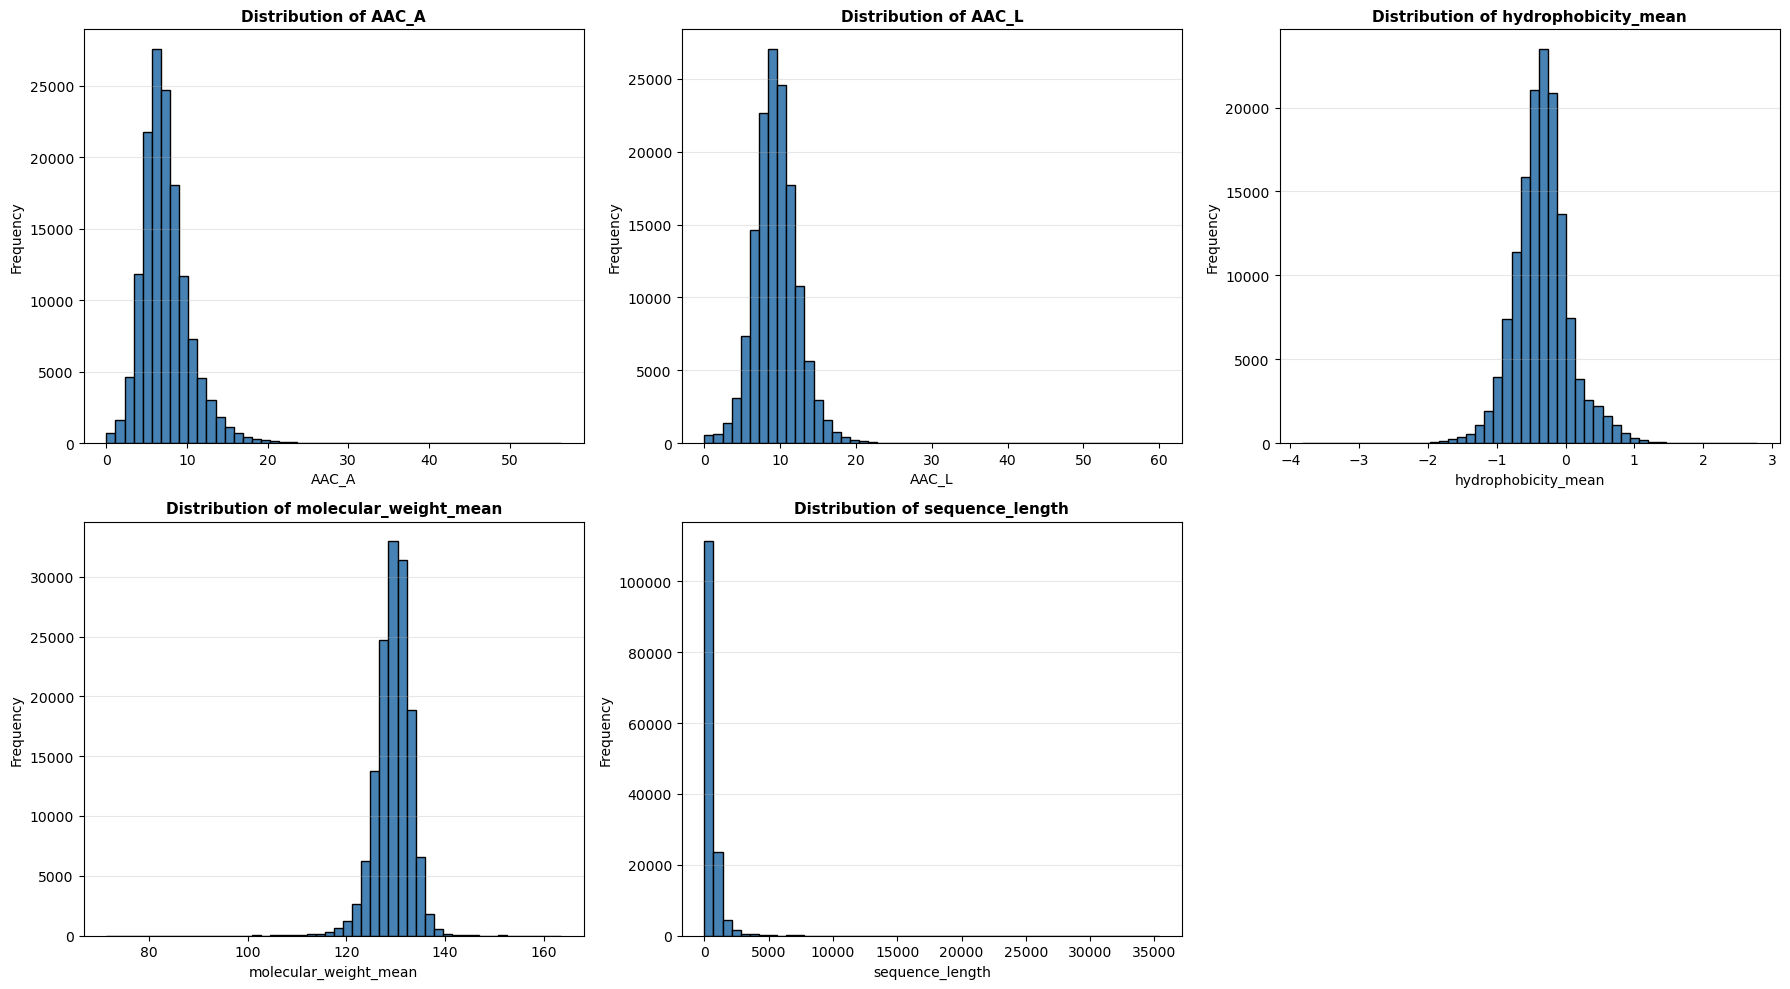


✓ Saved: visuals/05_feature_distributions.png


In [32]:
# Cell 8: Feature Statistics and Visualization
print("\n" + "="*70)
print("FEATURE STATISTICS")
print("="*70)

# Select numerical columns only
numerical_features = combined_features.select_dtypes(include=[np.number])

print(f"\nFeature statistics:")
print(numerical_features.describe())

# Visualize feature distributions (sample)
sample_features = ['AAC_A', 'AAC_L', 'hydrophobicity_mean', 'molecular_weight_mean', 'sequence_length']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(sample_features):
    if feature in numerical_features.columns:
        axes[idx].hist(numerical_features[feature], bins=50, 
                      color='steelblue', edgecolor='black')
        axes[idx].set_xlabel(feature, fontsize=10)
        axes[idx].set_ylabel('Frequency', fontsize=10)
        axes[idx].set_title(f'Distribution of {feature}', fontsize=11, fontweight='bold')
        axes[idx].grid(axis='y', alpha=0.3)

# Hide extra subplot
axes[-1].axis('off')

plt.tight_layout()
plt.savefig('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/visuals/05_feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: visuals/05_feature_distributions.png")


FEATURE CORRELATION ANALYSIS


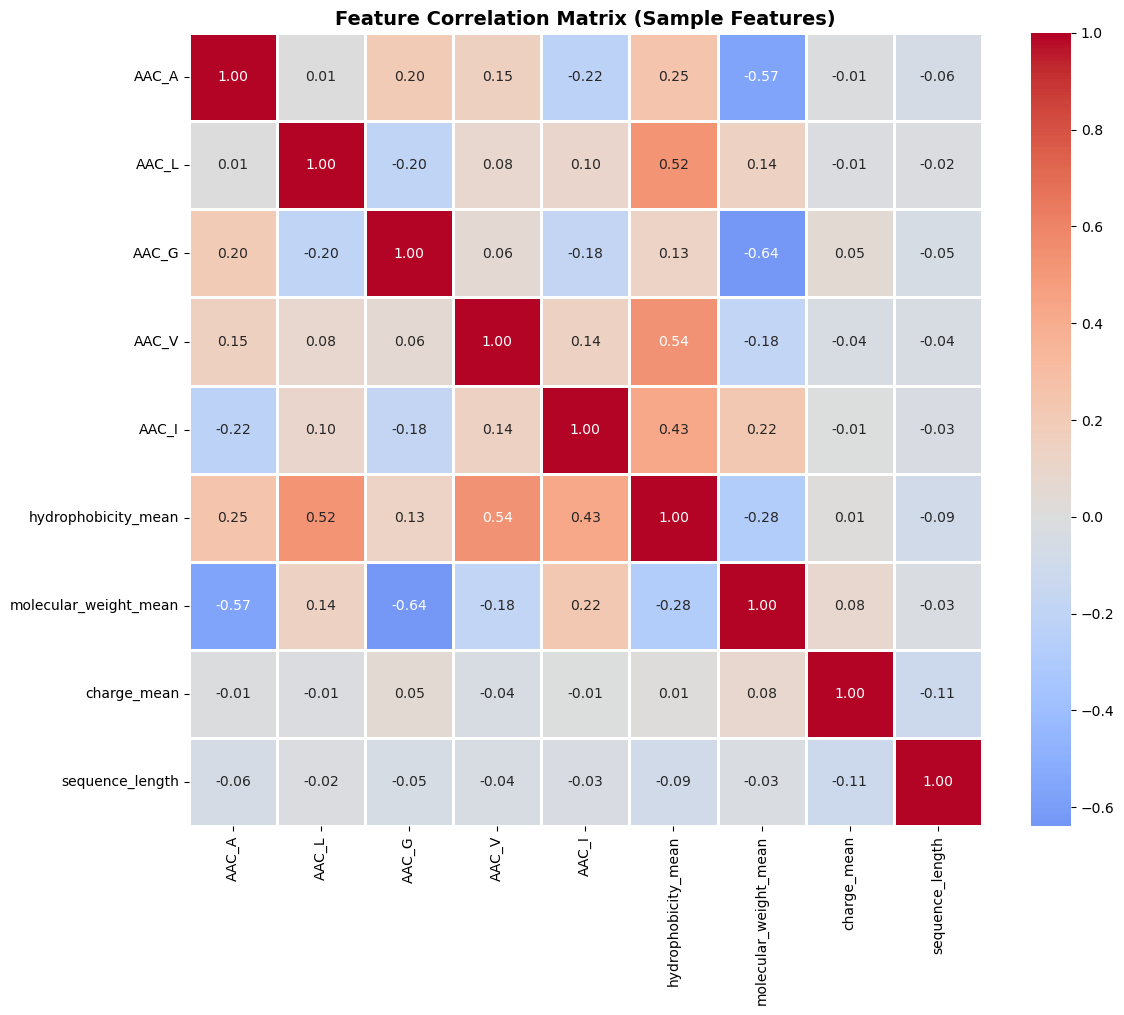


✓ Saved: visuals/06_feature_correlation.png

✓ No highly correlated features found


In [33]:
# Cell 9: Feature Correlation Analysis
print("\n" + "="*70)
print("FEATURE CORRELATION ANALYSIS")
print("="*70)

# Calculate correlation matrix (sample of features)
sample_feat_cols = ['AAC_A', 'AAC_L', 'AAC_G', 'AAC_V', 'AAC_I',
                    'hydrophobicity_mean', 'molecular_weight_mean', 
                    'charge_mean', 'sequence_length']

correlation_matrix = numerical_features[sample_feat_cols].corr()

# Visualize
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
           center=0, square=True, linewidths=1)
plt.title('Feature Correlation Matrix (Sample Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/visuals/06_feature_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: visuals/06_feature_correlation.png")

# Find highly correlated features
high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            high_corr.append((correlation_matrix.columns[i],
                            correlation_matrix.columns[j],
                            correlation_matrix.iloc[i, j]))

if high_corr:
    print(f"\n⚠️ Highly correlated features (|r| > 0.8):")
    for feat1, feat2, corr in high_corr:
        print(f"  {feat1} ↔ {feat2}: {corr:.3f}")
else:
    print(f"\n✓ No highly correlated features found")

In [34]:
# Cell 1: Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.model_selection import train_test_split
import pickle

print("="*70)
print("PREPARING TRAINING DATA")
print("="*70)

# Load features
features_df = pd.read_csv('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/data/features/protein_features_all.csv')

# Load protein data with GO terms
protein_df = pd.read_csv('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/data/processed/protein_dataset_with_go.csv')

print(f"\n✓ Features loaded: {features_df.shape}")
print(f"✓ Protein data loaded: {protein_df.shape}")

PREPARING TRAINING DATA

✓ Features loaded: (142246, 138)
✓ Protein data loaded: (142246, 11)


In [38]:
# Cell 2: Select Target GO Terms
print("\n" + "="*70)
print("SELECTING TARGET GO TERMS")
print("="*70)

# Strategy: Focus on most common GO terms to start
# This makes the problem more tractable

# Load GO term frequencies
go_mf_freq = pd.read_csv('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/data/processed/GO_MFO_frequencies.csv')
go_bp_freq = pd.read_csv('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/data/processed/GO_BPO_frequencies.csv')
go_cc_freq = pd.read_csv('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/data/processed/GO_CCO_frequencies.csv')

# Select top N GO terms from each category
TOP_N_PER_CATEGORY = 50  # Adjust based on computational resources

selected_go_mf = go_mf_freq.head(TOP_N_PER_CATEGORY)['term'].tolist()
selected_go_bp = go_bp_freq.head(TOP_N_PER_CATEGORY)['term'].tolist()
selected_go_cc = go_cc_freq.head(TOP_N_PER_CATEGORY)['term'].tolist()

selected_go_terms = {
    'MF': selected_go_mf,
    'BP': selected_go_bp,
    'CC': selected_go_cc
}

print(f"\n📊 SELECTED GO TERMS:")
print(f"  Molecular Function: {len(selected_go_mf)} terms")
print(f"  Biological Process: {len(selected_go_bp)} terms")
print(f"  Cellular Component: {len(selected_go_cc)} terms")
print(f"  Total: {len(selected_go_mf) + len(selected_go_bp) + len(selected_go_cc)} terms")

# Save selected GO terms
with open('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/data/processed/selected_go_terms.pkl', 'wb') as f:
    pickle.dump(selected_go_terms, f)

print("\n✓ Saved: data/processed/selected_go_terms.pkl")

# Display top 10 from each category
for category, go_list in selected_go_terms.items():
    print(f"\n{category} - Top 10:")
    for i, go_term in enumerate(go_list[:10], 1):
        print(f"  {i:2d}. {go_term}")


SELECTING TARGET GO TERMS

📊 SELECTED GO TERMS:
  Molecular Function: 50 terms
  Biological Process: 50 terms
  Cellular Component: 50 terms
  Total: 150 terms

✓ Saved: data/processed/selected_go_terms.pkl

MF - Top 10:
   1. GO:0003674
   2. GO:0005488
   3. GO:0005515
   4. GO:0003824
   5. GO:0097159
   6. GO:1901363
   7. GO:0003676
   8. GO:0016740
   9. GO:0016787
  10. GO:0140096

BP - Top 10:
   1. GO:0008150
   2. GO:0009987
   3. GO:0065007
   4. GO:0050789
   5. GO:0050794
   6. GO:0050896
   7. GO:0008152
   8. GO:0032501
   9. GO:0032502
  10. GO:0071704

CC - Top 10:
   1. GO:0005575
   2. GO:0110165
   3. GO:0005622
   4. GO:0043226
   5. GO:0043229
   6. GO:0043227
   7. GO:0005737
   8. GO:0043231
   9. GO:0005634
  10. GO:0016020


In [39]:
print(protein_df[['GO_MF', 'GO_BP', 'GO_CC']].head(5))

                                               GO_MF  \
0         ['GO:0005515', 'GO:0005488', 'GO:0003674']   
1  ['GO:0046982', 'GO:0003674', 'GO:0005488', 'GO...   
2  ['GO:0003676', 'GO:1990837', 'GO:0001216', 'GO...   
3  ['GO:0030674', 'GO:0003674', 'GO:1990756', 'GO...   
4  ['GO:0001227', 'GO:0042803', 'GO:0042802', 'GO...   

                                               GO_BP  \
0  ['GO:0008152', 'GO:0071897', 'GO:0044249', 'GO...   
1  ['GO:0061371', 'GO:0048589', 'GO:0051641', 'GO...   
2  ['GO:0006357', 'GO:0010557', 'GO:0045935', 'GO...   
3  ['GO:0008152', 'GO:0051234', 'GO:0036211', 'GO...   
4                                                 []   

                                               GO_CC  
0                                                 []  
1  ['GO:0071944', 'GO:0005575', 'GO:0110165', 'GO...  
2  ['GO:0005622', 'GO:0031981', 'GO:0043229', 'GO...  
3  ['GO:0065010', 'GO:0043226', 'GO:1903561', 'GO...  
4  ['GO:0005622', 'GO:0043229', 'GO:0043226', 'GO..

In [40]:
print("\n" + "="*70)
print("CREATING MULTI-LABEL TARGETS")
print("="*70)

def create_multilabel_target(protein_df, go_column, selected_terms):
    """
    Convert GO term column into a binary matrix for multi-label classification.
    Only selected GO terms are kept.
    """
    go_lists = []
    
    for go_str in protein_df[go_column]:
        if pd.isna(go_str) or go_str == '[]':
            go_lists.append([])
        else:
            # Parse string representation of list
            go_str = go_str.replace('[', '').replace(']', '').replace("'", "")
            if go_str:
                terms = [term.strip() for term in go_str.split(',')]
                # Filter to only selected terms
                terms = [t for t in terms if t in selected_terms]
                go_lists.append(terms)
            else:
                go_lists.append([])

    # MultiLabelBinarizer
    mlb = MultiLabelBinarizer(classes=selected_terms)
    binary_matrix = mlb.fit_transform(go_lists)
    
    return binary_matrix, mlb

# Molecular Function
y_mf, mlb_mf = create_multilabel_target(protein_df, 'GO_MF', selected_go_mf)
print(f"\n✓ MF targets created: {y_mf.shape}")
print(f"  Positive samples per term (mean): {y_mf.sum(axis=0).mean():.1f}")
print(f"  Labels per protein (mean): {y_mf.sum(axis=1).mean():.2f}")

# Biological Process
y_bp, mlb_bp = create_multilabel_target(protein_df, 'GO_BP', selected_go_bp)
print(f"\n✓ BP targets created: {y_bp.shape}")
print(f"  Positive samples per term (mean): {y_bp.sum(axis=0).mean():.1f}")
print(f"  Labels per protein (mean): {y_bp.sum(axis=1).mean():.2f}")

# Cellular Component
y_cc, mlb_cc = create_multilabel_target(protein_df, 'GO_CC', selected_go_cc)
print(f"\n✓ CC targets created: {y_cc.shape}")
print(f"  Positive samples per term (mean): {y_cc.sum(axis=0).mean():.1f}")
print(f"  Labels per protein (mean): {y_cc.sum(axis=1).mean():.2f}")

# Save MultiLabelBinarizers
with open('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/models/mlb_mf.pkl', 'wb') as f:
    pickle.dump(mlb_mf, f)
with open('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/models/mlb_bp.pkl', 'wb') as f:
    pickle.dump(mlb_bp, f)
with open('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/models/mlb_cc.pkl', 'wb') as f:
    pickle.dump(mlb_cc, f)

print("\n✓ Saved MultiLabelBinarizers")


CREATING MULTI-LABEL TARGETS

✓ MF targets created: (142246, 50)
  Positive samples per term (mean): 8010.7
  Labels per protein (mean): 2.82

✓ BP targets created: (142246, 50)
  Positive samples per term (mean): 20509.7
  Labels per protein (mean): 7.21

✓ CC targets created: (142246, 50)
  Positive samples per term (mean): 18380.8
  Labels per protein (mean): 6.46

✓ Saved MultiLabelBinarizers



LABEL DISTRIBUTION ANALYSIS


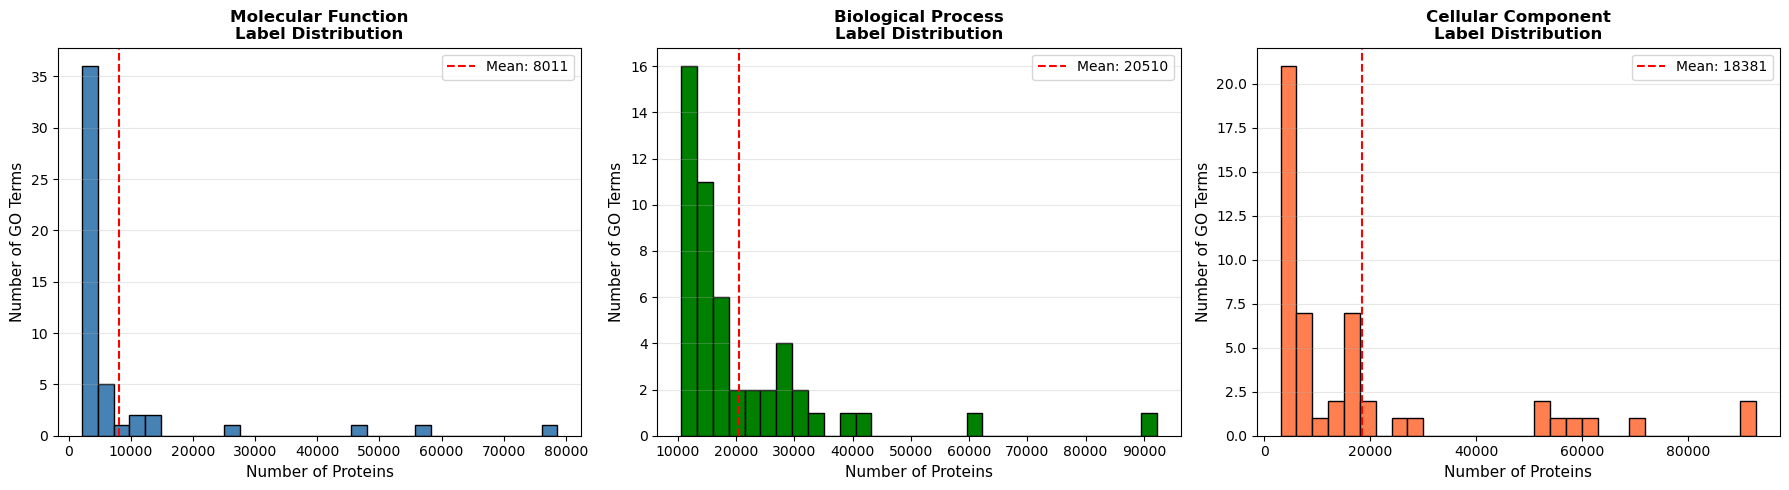


✓ Saved: visuals/07_label_distribution.png

Molecular Function:
  Total labels: 50
  Rare labels (<10 samples): 0
  Min count: 2098
  Max count: 78637

Biological Process:
  Total labels: 50
  Rare labels (<10 samples): 0
  Min count: 10613
  Max count: 92210

Cellular Component:
  Total labels: 50
  Rare labels (<10 samples): 0
  Min count: 3087
  Max count: 92912


In [41]:
# Cell 4: Analyze Label Distribution
print("\n" + "="*70)
print("LABEL DISTRIBUTION ANALYSIS")
print("="*70)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

categories = [
    (y_mf, 'Molecular Function', 'steelblue'),
    (y_bp, 'Biological Process', 'green'),
    (y_cc, 'Cellular Component', 'coral')
]

for idx, (y_matrix, title, color) in enumerate(categories):
    # Count positive samples per GO term
    term_counts = y_matrix.sum(axis=0)
    
    axes[idx].hist(term_counts, bins=30, color=color, edgecolor='black')
    axes[idx].set_xlabel('Number of Proteins', fontsize=11)
    axes[idx].set_ylabel('Number of GO Terms', fontsize=11)
    axes[idx].set_title(f'{title}\nLabel Distribution', fontsize=12, fontweight='bold')
    axes[idx].axvline(term_counts.mean(), color='red', linestyle='--',
                     label=f'Mean: {term_counts.mean():.0f}')
    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/visuals/07_label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: visuals/07_label_distribution.png")

# Identify rare labels
for idx, (y_matrix, title, color) in enumerate(categories):
    term_counts = y_matrix.sum(axis=0)
    rare_labels = (term_counts < 10).sum()
    print(f"\n{title}:")
    print(f"  Total labels: {len(term_counts)}")
    print(f"  Rare labels (<10 samples): {rare_labels}")
    print(f"  Min count: {term_counts.min()}")
    print(f"  Max count: {term_counts.max()}")

In [42]:
# Cell 5: Prepare Features (X)
print("\n" + "="*70)
print("PREPARING FEATURE MATRIX")
print("="*70)

# Remove non-feature columns
X = features_df.drop(['EntryID'], axis=1, errors='ignore')

print(f"\nFeature matrix shape: {X.shape}")
print(f"Features: {X.shape[1]}")

# Check for missing values
missing = X.isnull().sum()
if missing.sum() > 0:
    print(f"\n⚠️ Missing values found:")
    print(missing[missing > 0])
    # Fill with 0
    X = X.fillna(0)
    print("✓ Filled missing values with 0")
else:
    print("\n✓ No missing values")

# Check for infinite values
inf_count = np.isinf(X.values).sum()
if inf_count > 0:
    print(f"\n⚠️ Infinite values found: {inf_count}")
    X = X.replace([np.inf, -np.inf], 0)
    print("✓ Replaced infinite values with 0")
else:
    print("✓ No infinite values")


PREPARING FEATURE MATRIX

Feature matrix shape: (142246, 137)
Features: 137

✓ No missing values
✓ No infinite values


In [43]:
# Cell 6: Feature Scaling
print("\n" + "="*70)
print("FEATURE SCALING")
print("="*70)

# Standardize features (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n✓ Features scaled")
print(f"  Original range: {X.values.min():.2f} to {X.values.max():.2f}")
print(f"  Scaled range: {X_scaled.min():.2f} to {X_scaled.max():.2f}")
print(f"  Scaled mean: {X_scaled.mean():.6f}")
print(f"  Scaled std: {X_scaled.std():.6f}")

# Save scaler
with open('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/models/feature_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("\n✓ Saved: models/feature_scaler.pkl")


FEATURE SCALING

✓ Features scaled
  Original range: -4.50 to 35375.00
  Scaled range: -377.15 to 217.75
  Scaled mean: -0.000000
  Scaled std: 1.000000

✓ Saved: models/feature_scaler.pkl


In [44]:
# Cell 7: Train-Val-Test Split (for each GO category)
print("\n" + "="*70)
print("CREATING TRAIN-VAL-TEST SPLITS")
print("="*70)

# We'll create splits for Molecular Function (MF) first
# Same approach for BP and CC

# Split: 70% train, 15% val, 15% test
X_train_val, X_test, y_mf_train_val, y_mf_test = train_test_split(
    X_scaled, y_mf, test_size=0.15, random_state=42
)

X_train, X_val, y_mf_train, y_mf_val = train_test_split(
    X_train_val, y_mf_train_val, test_size=0.176, random_state=42  # 0.176 of 0.85 ≈ 0.15 of total
)

print(f"\n📊 MOLECULAR FUNCTION (MF) SPLITS:")
print(f"  Train: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Val:   {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Test:  {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Same splits for BP and CC (same protein splits)
_, _, y_bp_train_val, y_bp_test = train_test_split(
    X_scaled, y_bp, test_size=0.15, random_state=42
)
_, _, y_bp_train, y_bp_val = train_test_split(
    X_train_val, y_bp_train_val, test_size=0.176, random_state=42
)

_, _, y_cc_train_val, y_cc_test = train_test_split(
    X_scaled, y_cc, test_size=0.15, random_state=42
)
_, _, y_cc_train, y_cc_val = train_test_split(
    X_train_val, y_cc_train_val, test_size=0.176, random_state=42
)

print(f"\n✓ Splits created for all three GO categories")


CREATING TRAIN-VAL-TEST SPLITS

📊 MOLECULAR FUNCTION (MF) SPLITS:
  Train: 99,629 samples (70.0%)
  Val:   21,280 samples (15.0%)
  Test:  21,337 samples (15.0%)

✓ Splits created for all three GO categories


In [45]:
# Cell 8: Save Prepared Data
print("\n" + "="*70)
print("SAVING PREPARED DATASETS")
print("="*70)

# Save as numpy arrays for faster loading
np.save('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/data/processed/X_train.npy', X_train)
np.save('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/data/processed/X_val.npy', X_val)
np.save('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/data/processed/X_test.npy', X_test)

# Save targets for each category
for category, y_train, y_val, y_test in [
    ('MF', y_mf_train, y_mf_val, y_mf_test),
    ('BP', y_bp_train, y_bp_val, y_bp_test),
    ('CC', y_cc_train, y_cc_val, y_cc_test)
]:
    np.save(f'../data/processed/y_{category}_train.npy', y_train)
    np.save(f'../data/processed/y_{category}_val.npy', y_val)
    np.save(f'../data/processed/y_{category}_test.npy', y_test)
    print(f"✓ Saved {category} targets")

print("\n" + "="*70)
print("✓ ALL DATA PREPARED AND SAVED")
print("="*70)

print(f"\nFiles saved:")
print(f"  X_train.npy, X_val.npy, X_test.npy")
print(f"  y_MF_train.npy, y_MF_val.npy, y_MF_test.npy")
print(f"  y_BP_train.npy, y_BP_val.npy, y_BP_test.npy")
print(f"  y_CC_train.npy, y_CC_val.npy, y_CC_test.npy")


SAVING PREPARED DATASETS
✓ Saved MF targets
✓ Saved BP targets
✓ Saved CC targets

✓ ALL DATA PREPARED AND SAVED

Files saved:
  X_train.npy, X_val.npy, X_test.npy
  y_MF_train.npy, y_MF_val.npy, y_MF_test.npy
  y_BP_train.npy, y_BP_val.npy, y_BP_test.npy
  y_CC_train.npy, y_CC_val.npy, y_CC_test.npy


In [47]:
# Cell 9: Data Summary
print("\n" + "="*70)
print("DATA PREPARATION SUMMARY")
print("="*70)

summary = f"""
CAFA 5 - DATA PREPARATION COMPLETE

FEATURES:
- Total features extracted: {X.shape[1]}
  • Amino Acid Composition: 20
  • Physicochemical properties: 16
  • K-mer features: 100
  • Sequence length: 1

TARGETS:
- GO categories: 3 (MF, BP, CC)
- GO terms per category: {TOP_N_PER_CATEGORY}
- Total GO terms: {len(selected_go_mf) + len(selected_go_bp) + len(selected_go_cc)}

DATASET SPLITS:
- Training: {X_train.shape[0]:,} proteins (70%)
- Validation: {X_val.shape[0]:,} proteins (15%)
- Test: {X_test.shape[0]:,} proteins (15%)

MOLECULAR FUNCTION (MF):
- GO terms: {len(selected_go_mf)}
- Avg labels per protein: {y_mf.sum(axis=1).mean():.2f}
- Avg proteins per GO term: {y_mf.sum(axis=0).mean():.1f}

BIOLOGICAL PROCESS (BP):
- GO terms: {len(selected_go_bp)}
- Avg labels per protein: {y_bp.sum(axis=1).mean():.2f}
- Avg proteins per GO term: {y_bp.sum(axis=0).mean():.1f}

CELLULAR COMPONENT (CC):
- GO terms: {len(selected_go_cc)}
- Avg labels per protein: {y_cc.sum(axis=1).mean():.2f}
- Avg proteins per GO term: {y_cc.sum(axis=0).mean():.1f}

FEATURE PREPROCESSING:
- Missing values: Filled with 0
- Infinite values: Replaced with 0
- Scaling: StandardScaler (mean=0, std=1)

READY FOR MODELING: YES ✓

NEXT STEPS:
1. Build baseline models (Logistic Regression, Random Forest, XGBoost)
2. Deep learning models (LSTM, CNN, Attention)
3. Evaluate with CAFA metrics
4. Hyperparameter tuning
5. Ensemble methods
"""

print(summary)

# Save summary with UTF-8 encoding
with open('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/reports/02_data_preparation_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary)

print("\n✓ Saved: reports/02_data_preparation_summary.txt")


DATA PREPARATION SUMMARY

CAFA 5 - DATA PREPARATION COMPLETE

FEATURES:
- Total features extracted: 137
  • Amino Acid Composition: 20
  • Physicochemical properties: 16
  • K-mer features: 100
  • Sequence length: 1

TARGETS:
- GO categories: 3 (MF, BP, CC)
- GO terms per category: 50
- Total GO terms: 150

DATASET SPLITS:
- Training: 99,629 proteins (70%)
- Validation: 21,280 proteins (15%)
- Test: 21,337 proteins (15%)

MOLECULAR FUNCTION (MF):
- GO terms: 50
- Avg labels per protein: 2.82
- Avg proteins per GO term: 8010.7

BIOLOGICAL PROCESS (BP):
- GO terms: 50
- Avg labels per protein: 7.21
- Avg proteins per GO term: 20509.7

CELLULAR COMPONENT (CC):
- GO terms: 50
- Avg labels per protein: 6.46
- Avg proteins per GO term: 18380.8

FEATURE PREPROCESSING:
- Missing values: Filled with 0
- Infinite values: Replaced with 0
- Scaling: StandardScaler (mean=0, std=1)

READY FOR MODELING: YES ✓

NEXT STEPS:
1. Build baseline models (Logistic Regression, Random Forest, XGBoost)
2. Dee

In [48]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (hamming_loss, accuracy_score, precision_score, 
                             recall_score, f1_score, classification_report,
                             multilabel_confusion_matrix)
import pickle
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("BASELINE MODELS - PROTEIN FUNCTION PREDICTION")
print("="*70)

BASELINE MODELS - PROTEIN FUNCTION PREDICTION


In [49]:
# Cell 2: Load Prepared Data
print("\n" + "="*70)
print("LOADING DATA")
print("="*70)

# Load features
X_train = np.load('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/data/processed/X_train.npy')
X_val = np.load('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/data/processed/X_val.npy')
X_test = np.load('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/data/processed/X_test.npy')

print(f"✓ Features loaded")
print(f"  X_train: {X_train.shape}")
print(f"  X_val: {X_val.shape}")
print(f"  X_test: {X_test.shape}")

# Load targets for Molecular Function (MF) first
y_mf_train = np.load('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/data/processed/y_MF_train.npy')
y_mf_val = np.load('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/data/processed/y_MF_val.npy')
y_mf_test = np.load('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/data/processed/y_MF_test.npy')

print(f"\n✓ Molecular Function targets loaded")
print(f"  y_MF_train: {y_mf_train.shape}")
print(f"  y_MF_val: {y_mf_val.shape}")
print(f"  y_MF_test: {y_mf_test.shape}")

# Load MultiLabelBinarizer
with open('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/models/mlb_mf.pkl', 'rb') as f:
    mlb_mf = pickle.load(f)

print(f"\n✓ MultiLabelBinarizer loaded")
print(f"  GO terms: {len(mlb_mf.classes_)}")


LOADING DATA
✓ Features loaded
  X_train: (99629, 137)
  X_val: (21280, 137)
  X_test: (21337, 137)

✓ Molecular Function targets loaded
  y_MF_train: (99629, 50)
  y_MF_val: (21280, 50)
  y_MF_test: (21337, 50)

✓ MultiLabelBinarizer loaded
  GO terms: 50


In [50]:
# Cell 3: Define Evaluation Metrics
print("\n" + "="*70)
print("DEFINING EVALUATION METRICS")
print("="*70)

def evaluate_multilabel_model(y_true, y_pred, model_name="Model"):
    """
    Comprehensive evaluation for multi-label classification
    """
    metrics = {}
    
    # Hamming Loss (lower is better)
    metrics['hamming_loss'] = hamming_loss(y_true, y_pred)
    
    # Subset Accuracy (exact match)
    metrics['subset_accuracy'] = accuracy_score(y_true, y_pred)
    
    # Label-based metrics (micro, macro, weighted, samples)
    for avg in ['micro', 'macro', 'weighted', 'samples']:
        metrics[f'precision_{avg}'] = precision_score(y_true, y_pred, average=avg, zero_division=0)
        metrics[f'recall_{avg}'] = recall_score(y_true, y_pred, average=avg, zero_division=0)
        metrics[f'f1_{avg}'] = f1_score(y_true, y_pred, average=avg, zero_division=0)
    
    return metrics

def print_metrics(metrics, model_name="Model"):
    """Pretty print metrics"""
    print(f"\n{'='*70}")
    print(f"{model_name} - EVALUATION METRICS")
    print(f"{'='*70}")
    
    print(f"\n📊 OVERALL METRICS:")
    print(f"  Hamming Loss: {metrics['hamming_loss']:.4f} (lower is better)")
    print(f"  Subset Accuracy: {metrics['subset_accuracy']:.4f} (exact match)")
    
    print(f"\n📊 PRECISION:")
    print(f"  Micro: {metrics['precision_micro']:.4f}")
    print(f"  Macro: {metrics['precision_macro']:.4f}")
    print(f"  Weighted: {metrics['precision_weighted']:.4f}")
    print(f"  Samples: {metrics['precision_samples']:.4f}")
    
    print(f"\n📊 RECALL:")
    print(f"  Micro: {metrics['recall_micro']:.4f}")
    print(f"  Macro: {metrics['recall_macro']:.4f}")
    print(f"  Weighted: {metrics['recall_weighted']:.4f}")
    print(f"  Samples: {metrics['recall_samples']:.4f}")
    
    print(f"\n📊 F1-SCORE:")
    print(f"  Micro: {metrics['f1_micro']:.4f}")
    print(f"  Macro: {metrics['f1_macro']:.4f}")
    print(f"  Weighted: {metrics['f1_weighted']:.4f}")
    print(f"  Samples: {metrics['f1_samples']:.4f}")

print("✓ Evaluation functions defined")


DEFINING EVALUATION METRICS
✓ Evaluation functions defined


In [51]:
# Cell 4: Baseline Model 1 - Logistic Regression
print("\n" + "="*70)
print("MODEL 1: LOGISTIC REGRESSION (Multi-Label)")
print("="*70)

print("\nTraining Logistic Regression...")
print("Note: This may take 10-15 minutes for multi-label classification")

# Use OneVsRest strategy (train one classifier per label)
lr_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1,
    solver='lbfgs'
)

# Wrap in MultiOutputClassifier for multi-label
lr_model = MultiOutputClassifier(lr_classifier, n_jobs=-1)

# Train
print("\nTraining started...")
lr_model.fit(X_train, y_mf_train)
print("✓ Training complete")

# Predict on validation set
print("\nPredicting on validation set...")
y_val_pred_lr = lr_model.predict(X_val)

# Evaluate
val_metrics_lr = evaluate_multilabel_model(y_mf_val, y_val_pred_lr, "Logistic Regression")
print_metrics(val_metrics_lr, "Logistic Regression - Validation Set")

# Save model
with open('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/models/lr_model_mf.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
print("\n✓ Saved: models/lr_model_mf.pkl")


MODEL 1: LOGISTIC REGRESSION (Multi-Label)

Training Logistic Regression...
Note: This may take 10-15 minutes for multi-label classification

Training started...
✓ Training complete

Predicting on validation set...

Logistic Regression - Validation Set - EVALUATION METRICS

📊 OVERALL METRICS:
  Hamming Loss: 0.0538 (lower is better)
  Subset Accuracy: 0.0909 (exact match)

📊 PRECISION:
  Micro: 0.5541
  Macro: 0.1514
  Weighted: 0.3460
  Samples: 0.4890

📊 RECALL:
  Micro: 0.2175
  Macro: 0.0264
  Weighted: 0.2175
  Samples: 0.1565

📊 F1-SCORE:
  Micro: 0.3123
  Macro: 0.0281
  Weighted: 0.2023
  Samples: 0.2204

✓ Saved: models/lr_model_mf.pkl


In [52]:
# Cell 5: Baseline Model 2 - Random Forest
print("\n" + "="*70)
print("MODEL 2: RANDOM FOREST (Multi-Label)")
print("="*70)

print("\nTraining Random Forest...")
print("Note: This may take 15-20 minutes")

# Random Forest with moderate parameters
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_model = MultiOutputClassifier(rf_classifier, n_jobs=-1)

# Train
print("\nTraining started...")
rf_model.fit(X_train, y_mf_train)
print("✓ Training complete")

# Predict
print("\nPredicting on validation set...")
y_val_pred_rf = rf_model.predict(X_val)

# Evaluate
val_metrics_rf = evaluate_multilabel_model(y_mf_val, y_val_pred_rf, "Random Forest")
print_metrics(val_metrics_rf, "Random Forest - Validation Set")

# Save model
with open('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/models/rf_model_mf.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print("\n✓ Saved: models/rf_model_mf.pkl")


MODEL 2: RANDOM FOREST (Multi-Label)

Training Random Forest...
Note: This may take 15-20 minutes

Training started...
✓ Training complete

Predicting on validation set...

Random Forest - Validation Set - EVALUATION METRICS

📊 OVERALL METRICS:
  Hamming Loss: 0.0500 (lower is better)
  Subset Accuracy: 0.1857 (exact match)

📊 PRECISION:
  Micro: 0.6378
  Macro: 0.6761
  Weighted: 0.6810
  Samples: 0.4758

📊 RECALL:
  Micro: 0.2535
  Macro: 0.0538
  Weighted: 0.2535
  Samples: 0.1767

📊 F1-SCORE:
  Micro: 0.3628
  Macro: 0.0778
  Weighted: 0.2682
  Samples: 0.2369

✓ Saved: models/rf_model_mf.pkl


In [53]:
# Cell 6: Baseline Model 3 - XGBoost
print("\n" + "="*70)
print("MODEL 3: XGBOOST (Multi-Label)")
print("="*70)

print("\nTraining XGBoost...")
print("Note: This may take 20-30 minutes")

# XGBoost classifier
xgb_classifier = XGBClassifier(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    tree_method='hist'  # Faster training
)

xgb_model = MultiOutputClassifier(xgb_classifier, n_jobs=-1)

# Train
print("\nTraining started...")
xgb_model.fit(X_train, y_mf_train)
print("✓ Training complete")

# Predict
print("\nPredicting on validation set...")
y_val_pred_xgb = xgb_model.predict(X_val)

# Evaluate
val_metrics_xgb = evaluate_multilabel_model(y_mf_val, y_val_pred_xgb, "XGBoost")
print_metrics(val_metrics_xgb, "XGBoost - Validation Set")

# Save model
with open('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/models/xgb_model_mf.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
print("\n✓ Saved: models/xgb_model_mf.pkl")


MODEL 3: XGBOOST (Multi-Label)

Training XGBoost...
Note: This may take 20-30 minutes

Training started...
✓ Training complete

Predicting on validation set...

XGBoost - Validation Set - EVALUATION METRICS

📊 OVERALL METRICS:
  Hamming Loss: 0.0490 (lower is better)
  Subset Accuracy: 0.2349 (exact match)

📊 PRECISION:
  Micro: 0.6281
  Macro: 0.6215
  Weighted: 0.6233
  Samples: 0.4348

📊 RECALL:
  Micro: 0.3107
  Macro: 0.1461
  Weighted: 0.3107
  Samples: 0.2053

📊 F1-SCORE:
  Micro: 0.4158
  Macro: 0.2152
  Weighted: 0.3586
  Samples: 0.2552

✓ Saved: models/xgb_model_mf.pkl


In [54]:
# Cell 7: Model Comparison
print("\n" + "="*70)
print("MODEL COMPARISON - VALIDATION SET")
print("="*70)

# Compile metrics
comparison_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Hamming_Loss': [
        val_metrics_lr['hamming_loss'],
        val_metrics_rf['hamming_loss'],
        val_metrics_xgb['hamming_loss']
    ],
    'Subset_Accuracy': [
        val_metrics_lr['subset_accuracy'],
        val_metrics_rf['subset_accuracy'],
        val_metrics_xgb['subset_accuracy']
    ],
    'F1_Micro': [
        val_metrics_lr['f1_micro'],
        val_metrics_rf['f1_micro'],
        val_metrics_xgb['f1_micro']
    ],
    'F1_Macro': [
        val_metrics_lr['f1_macro'],
        val_metrics_rf['f1_macro'],
        val_metrics_xgb['f1_macro']
    ],
    'Precision_Micro': [
        val_metrics_lr['precision_micro'],
        val_metrics_rf['precision_micro'],
        val_metrics_xgb['precision_micro']
    ],
    'Recall_Micro': [
        val_metrics_lr['recall_micro'],
        val_metrics_rf['recall_micro'],
        val_metrics_xgb['recall_micro']
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n", comparison_df.to_string(index=False))

# Save comparison
comparison_df.to_csv('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/reports/baseline_model_comparison.csv', index=False)
print("\n✓ Saved: reports/baseline_model_comparison.csv")


MODEL COMPARISON - VALIDATION SET

               Model  Hamming_Loss  Subset_Accuracy  F1_Micro  F1_Macro  Precision_Micro  Recall_Micro
Logistic Regression      0.053766         0.090930  0.312341  0.028094         0.554101      0.217461
      Random Forest      0.050000         0.185667  0.362813  0.077762         0.637780      0.253515
            XGBoost      0.049034         0.234868  0.415754  0.215237         0.628104      0.310709

✓ Saved: reports/baseline_model_comparison.csv


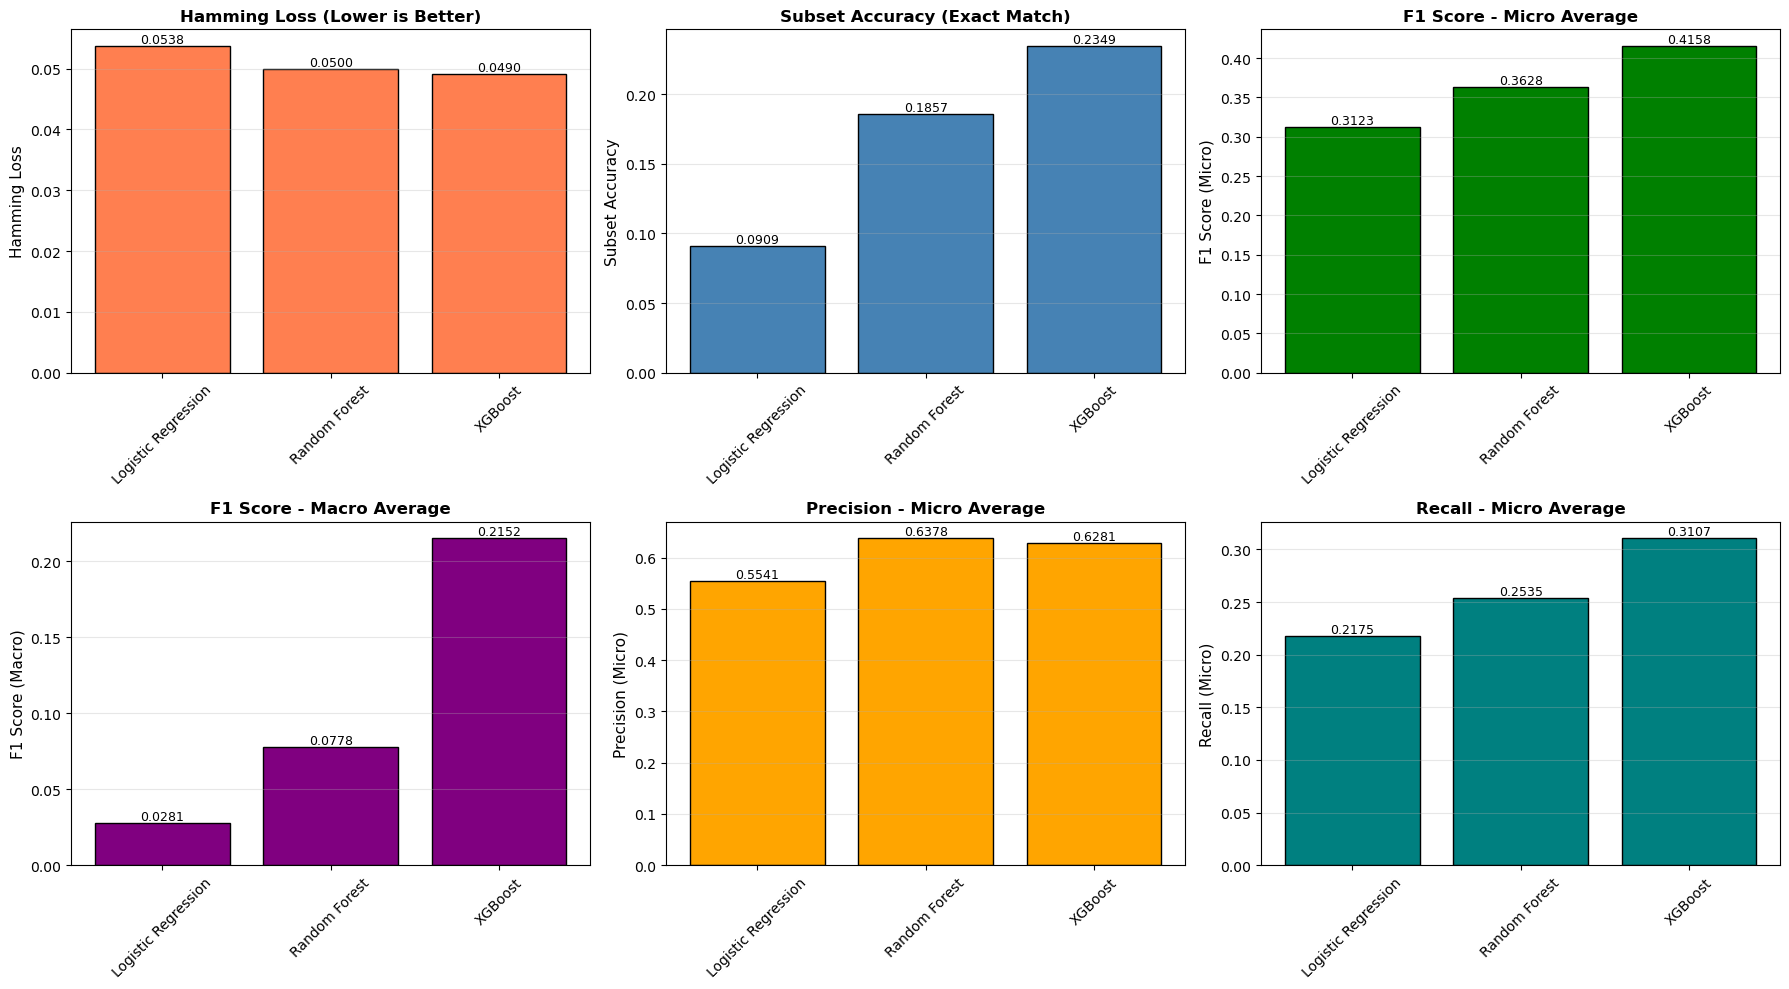


✓ Saved: visuals/08_baseline_model_comparison.png


In [55]:
# Cell 8: Visualize Model Comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

models = comparison_df['Model']

# Hamming Loss
axes[0, 0].bar(models, comparison_df['Hamming_Loss'], 
              color='coral', edgecolor='black')
axes[0, 0].set_ylabel('Hamming Loss', fontsize=11)
axes[0, 0].set_title('Hamming Loss (Lower is Better)', fontsize=12, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_df['Hamming_Loss']):
    axes[0, 0].text(i, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

# Subset Accuracy
axes[0, 1].bar(models, comparison_df['Subset_Accuracy'],
              color='steelblue', edgecolor='black')
axes[0, 1].set_ylabel('Subset Accuracy', fontsize=11)
axes[0, 1].set_title('Subset Accuracy (Exact Match)', fontsize=12, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_df['Subset_Accuracy']):
    axes[0, 1].text(i, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

# F1 Micro
axes[0, 2].bar(models, comparison_df['F1_Micro'],
              color='green', edgecolor='black')
axes[0, 2].set_ylabel('F1 Score (Micro)', fontsize=11)
axes[0, 2].set_title('F1 Score - Micro Average', fontsize=12, fontweight='bold')
axes[0, 2].tick_params(axis='x', rotation=45)
axes[0, 2].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_df['F1_Micro']):
    axes[0, 2].text(i, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

# F1 Macro
axes[1, 0].bar(models, comparison_df['F1_Macro'],
              color='purple', edgecolor='black')
axes[1, 0].set_ylabel('F1 Score (Macro)', fontsize=11)
axes[1, 0].set_title('F1 Score - Macro Average', fontsize=12, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_df['F1_Macro']):
    axes[1, 0].text(i, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

# Precision Micro
axes[1, 1].bar(models, comparison_df['Precision_Micro'],
              color='orange', edgecolor='black')
axes[1, 1].set_ylabel('Precision (Micro)', fontsize=11)
axes[1, 1].set_title('Precision - Micro Average', fontsize=12, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_df['Precision_Micro']):
    axes[1, 1].text(i, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

# Recall Micro
axes[1, 2].bar(models, comparison_df['Recall_Micro'],
              color='teal', edgecolor='black')
axes[1, 2].set_ylabel('Recall (Micro)', fontsize=11)
axes[1, 2].set_title('Recall - Micro Average', fontsize=12, fontweight='bold')
axes[1, 2].tick_params(axis='x', rotation=45)
axes[1, 2].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_df['Recall_Micro']):
    axes[1, 2].text(i, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/visuals/08_baseline_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: visuals/08_baseline_model_comparison.png")

In [56]:
# Cell 9: Select Best Model and Evaluate on Test Set
print("\n" + "="*70)
print("BEST MODEL EVALUATION ON TEST SET")
print("="*70)

# Select best based on F1_Micro
best_idx = comparison_df['F1_Micro'].idxmax()
best_model_name = comparison_df.loc[best_idx, 'Model']

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Validation F1 (Micro): {comparison_df.loc[best_idx, 'F1_Micro']:.4f}")

# Load best model
if best_model_name == 'Logistic Regression':
    best_model = lr_model
    y_val_pred_best = y_val_pred_lr
elif best_model_name == 'Random Forest':
    best_model = rf_model
    y_val_pred_best = y_val_pred_rf
else:
    best_model = xgb_model
    y_val_pred_best = y_val_pred_xgb

# Predict on test set
print(f"\nPredicting on test set with {best_model_name}...")
y_test_pred = best_model.predict(X_test)

# Evaluate
test_metrics = evaluate_multilabel_model(y_mf_test, y_test_pred, best_model_name)
print_metrics(test_metrics, f"{best_model_name} - TEST SET")

# Save test predictions
np.save('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/results/y_test_pred_baseline.npy', y_test_pred)
print("\n✓ Saved: results/y_test_pred_baseline.npy")

# Save test metrics
with open('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/results/test_metrics_baseline.pkl', 'wb') as f:
    pickle.dump(test_metrics, f)
print("✓ Saved: results/test_metrics_baseline.pkl")


BEST MODEL EVALUATION ON TEST SET

🏆 BEST MODEL: XGBoost
   Validation F1 (Micro): 0.4158

Predicting on test set with XGBoost...

XGBoost - TEST SET - EVALUATION METRICS

📊 OVERALL METRICS:
  Hamming Loss: 0.0490 (lower is better)
  Subset Accuracy: 0.2367 (exact match)

📊 PRECISION:
  Micro: 0.6270
  Macro: 0.6015
  Weighted: 0.6156
  Samples: 0.4352

📊 RECALL:
  Micro: 0.3085
  Macro: 0.1384
  Weighted: 0.3085
  Samples: 0.2045

📊 F1-SCORE:
  Micro: 0.4135
  Macro: 0.2048
  Weighted: 0.3551
  Samples: 0.2549

✓ Saved: results/y_test_pred_baseline.npy
✓ Saved: results/test_metrics_baseline.pkl


In [57]:
# Cell 10: Per-Label Performance Analysis
print("\n" + "="*70)
print("PER-LABEL PERFORMANCE ANALYSIS")
print("="*70)

# Calculate per-label F1 scores
per_label_f1 = []
per_label_precision = []
per_label_recall = []
per_label_support = []

num_labels = y_mf_test.shape[1]

for i in range(num_labels):
    # Per-label metrics
    precision = precision_score(y_mf_test[:, i], y_test_pred[:, i], zero_division=0)
    recall = recall_score(y_mf_test[:, i], y_test_pred[:, i], zero_division=0)
    f1 = f1_score(y_mf_test[:, i], y_test_pred[:, i], zero_division=0)
    support = y_mf_test[:, i].sum()
    
    per_label_f1.append(f1)
    per_label_precision.append(precision)
    per_label_recall.append(recall)
    per_label_support.append(support)

# Create DataFrame
per_label_df = pd.DataFrame({
    'GO_Term': mlb_mf.classes_,
    'Precision': per_label_precision,
    'Recall': per_label_recall,
    'F1_Score': per_label_f1,
    'Support': per_label_support
})

# Sort by F1 score
per_label_df = per_label_df.sort_values('F1_Score', ascending=False)

print("\n📊 TOP 20 BEST PERFORMING GO TERMS:")
print(per_label_df.head(20).to_string(index=False))

print("\n📊 BOTTOM 20 WORST PERFORMING GO TERMS:")
print(per_label_df.tail(20).to_string(index=False))

# Save
per_label_df.to_csv('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/results/per_label_performance.csv', index=False)
print("\n✓ Saved: results/per_label_performance.csv")


PER-LABEL PERFORMANCE ANALYSIS

📊 TOP 20 BEST PERFORMING GO TERMS:
   GO_Term  Precision   Recall  F1_Score  Support
GO:0003674   0.634596 0.783472  0.701219    11786
GO:0005488   0.606854 0.391118  0.475668     8647
GO:0004888   0.725490 0.349057  0.471338      318
GO:0060089   0.698980 0.324645  0.443366      422
GO:0038023   0.696809 0.315663  0.434494      415
GO:0005215   0.686869 0.301329  0.418891      677
GO:0022857   0.682143 0.297045  0.413868      643
GO:0003824   0.638956 0.277470  0.386919     3795
GO:0015075   0.750000 0.252717  0.378049      368
GO:0008324   0.755319 0.235099  0.358586      302
GO:0015318   0.728972 0.231454  0.351351      337
GO:0005515   0.596602 0.247718  0.350078     7230
GO:0004672   0.666667 0.189024  0.294537      328
GO:0016301   0.627451 0.136752  0.224561      468
GO:0003700   0.594059 0.134529  0.219378      446
GO:0140110   0.633333 0.132174  0.218705      575
GO:0016773   0.654762 0.130332  0.217391      422
GO:0003677   0.646409 0.122129  

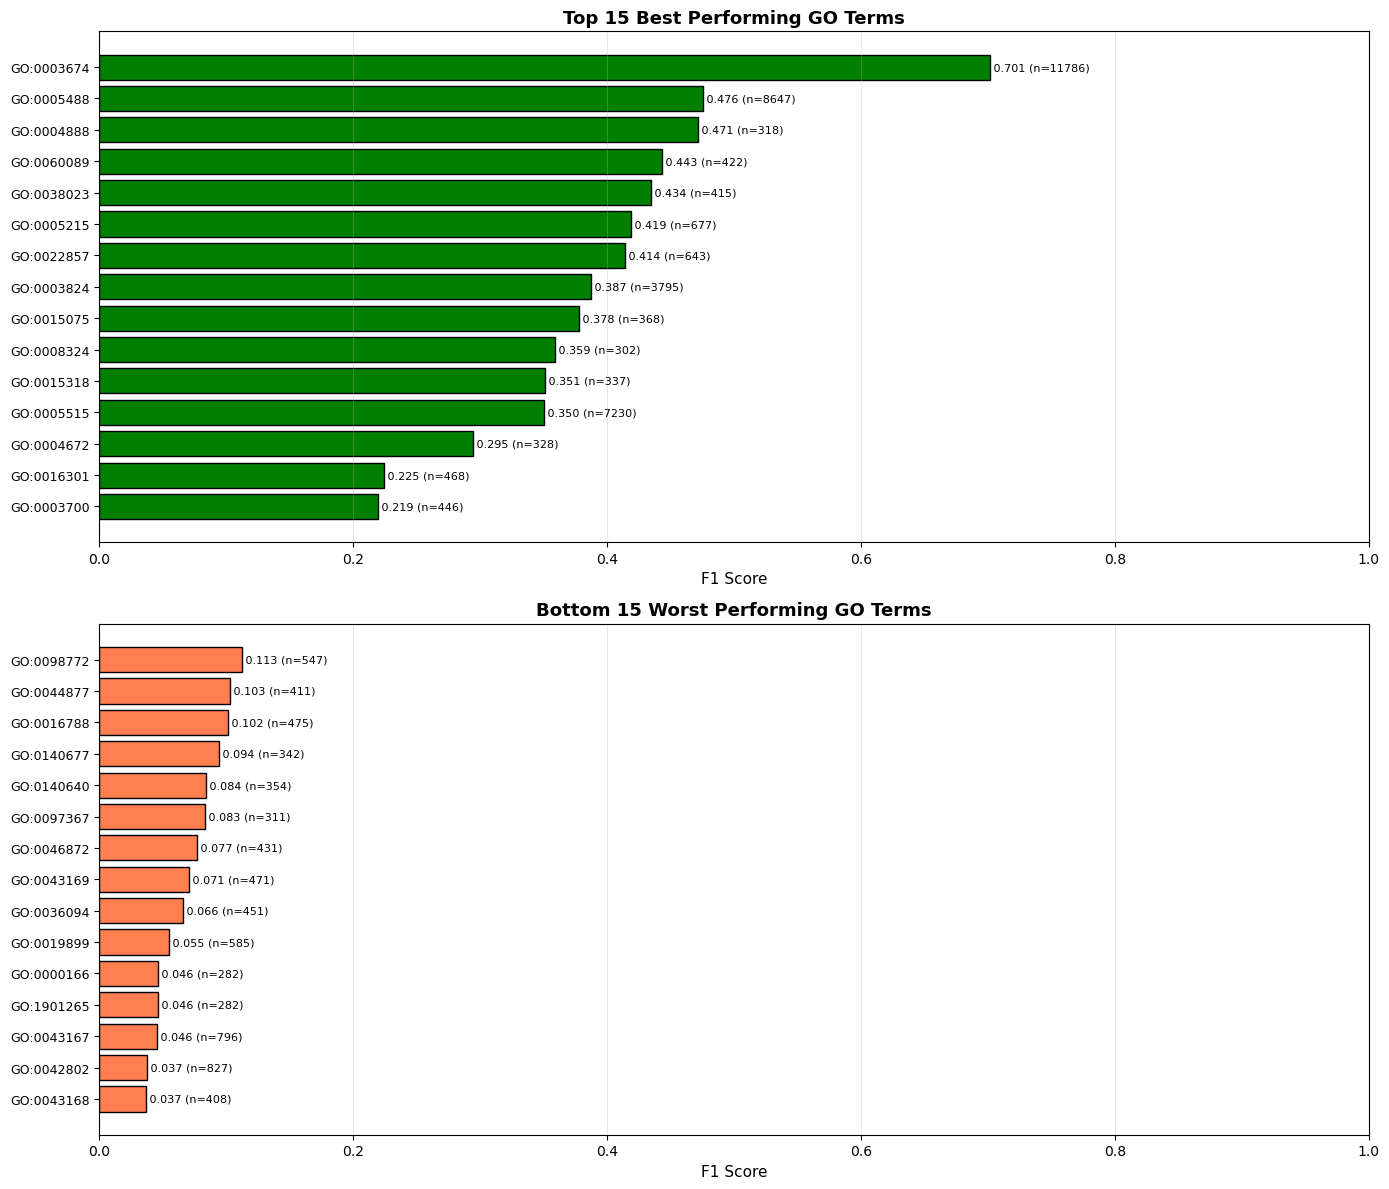


✓ Saved: visuals/09_per_label_performance.png


In [58]:
# Cell 11: Visualize Per-Label Performance
# Top 15 and Bottom 15
top_15 = per_label_df.head(15)
bottom_15 = per_label_df.tail(15)

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Top performers
axes[0].barh(range(len(top_15)), top_15['F1_Score'], color='green', edgecolor='black')
axes[0].set_yticks(range(len(top_15)))
axes[0].set_yticklabels(top_15['GO_Term'], fontsize=9)
axes[0].set_xlabel('F1 Score', fontsize=11)
axes[0].set_title('Top 15 Best Performing GO Terms', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)
axes[0].set_xlim([0, 1])

for i, (f1, support) in enumerate(zip(top_15['F1_Score'], top_15['Support'])):
    axes[0].text(f1, i, f' {f1:.3f} (n={int(support)})', va='center', fontsize=8)

# Bottom performers
axes[1].barh(range(len(bottom_15)), bottom_15['F1_Score'], color='coral', edgecolor='black')
axes[1].set_yticks(range(len(bottom_15)))
axes[1].set_yticklabels(bottom_15['GO_Term'], fontsize=9)
axes[1].set_xlabel('F1 Score', fontsize=11)
axes[1].set_title('Bottom 15 Worst Performing GO Terms', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)
axes[1].set_xlim([0, 1])

for i, (f1, support) in enumerate(zip(bottom_15['F1_Score'], bottom_15['Support'])):
    axes[1].text(f1, i, f' {f1:.3f} (n={int(support)})', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/visuals/09_per_label_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: visuals/09_per_label_performance.png")


SUPPORT vs PERFORMANCE CORRELATION

Correlation between Support and F1 Score: 0.5711


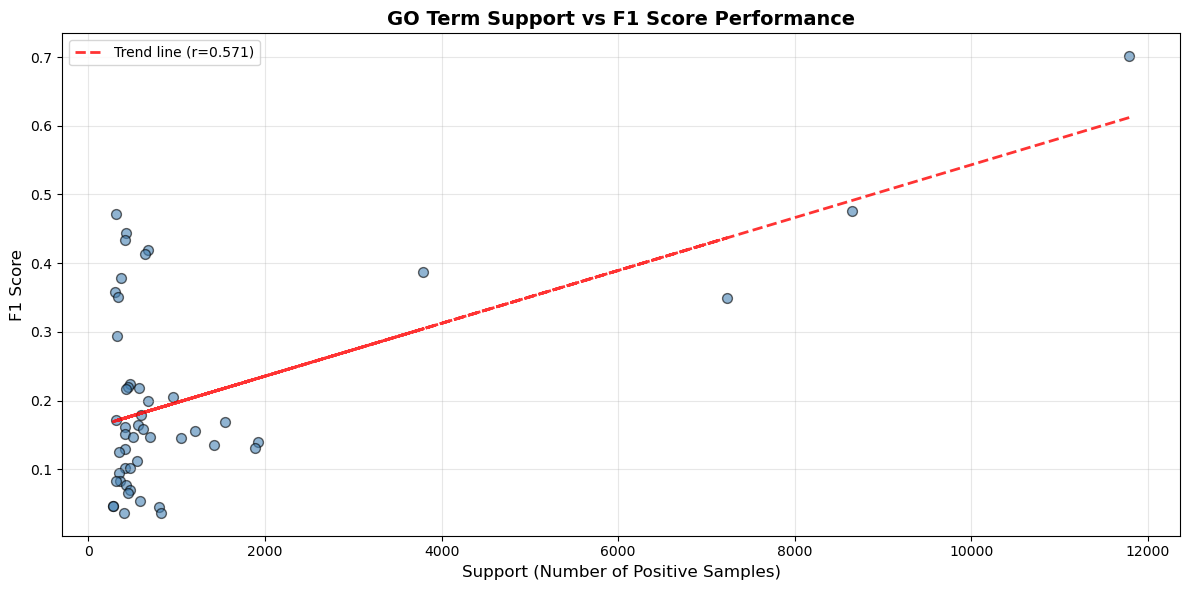


✓ Saved: visuals/10_support_vs_performance.png

💡 INSIGHT: Positive correlation - more training samples lead to better performance
   Recommendation: Focus on collecting more data for rare GO terms


In [59]:
# Cell 12: Support vs Performance Analysis
print("\n" + "="*70)
print("SUPPORT vs PERFORMANCE CORRELATION")
print("="*70)

# Analyze if label frequency affects performance
correlation = per_label_df[['Support', 'F1_Score']].corr()
print(f"\nCorrelation between Support and F1 Score: {correlation.iloc[0, 1]:.4f}")

# Visualize
plt.figure(figsize=(12, 6))
plt.scatter(per_label_df['Support'], per_label_df['F1_Score'], 
           alpha=0.6, s=50, color='steelblue', edgecolor='black')
plt.xlabel('Support (Number of Positive Samples)', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title('GO Term Support vs F1 Score Performance', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(per_label_df['Support'], per_label_df['F1_Score'], 1)
p = np.poly1d(z)
plt.plot(per_label_df['Support'], p(per_label_df['Support']), 
        "r--", alpha=0.8, linewidth=2, label=f'Trend line (r={correlation.iloc[0, 1]:.3f})')
plt.legend()

plt.tight_layout()
plt.savefig('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/visuals/10_support_vs_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: visuals/10_support_vs_performance.png")

if correlation.iloc[0, 1] > 0.3:
    print("\n💡 INSIGHT: Positive correlation - more training samples lead to better performance")
    print("   Recommendation: Focus on collecting more data for rare GO terms")
elif correlation.iloc[0, 1] < -0.3:
    print("\n💡 INSIGHT: Negative correlation - rare terms are easier to predict")
else:
    print("\n💡 INSIGHT: Weak correlation - support doesn't strongly affect performance")

In [61]:
# Cell 13: Sample Predictions Analysis
print("\n" + "="*70)
print("SAMPLE PREDICTIONS ANALYSIS")
print("="*70)

# Select 10 random test samples
sample_indices = np.random.choice(len(y_mf_test), 10, replace=False)

print("\n📊 SAMPLE PREDICTIONS:")
print("="*70)

for idx in sample_indices:
    true_labels = mlb_mf.inverse_transform(y_mf_test[idx:idx+1])[0]
    pred_labels = mlb_mf.inverse_transform(y_test_pred[idx:idx+1])[0]
    
    print(f"\nSample {idx}:")
    print(f"  True GO terms ({len(true_labels)}): {list(true_labels)}")
    print(f"  Predicted GO terms ({len(pred_labels)}): {list(pred_labels)}")
    
    # Calculate overlap
    true_set = set(true_labels)
    pred_set = set(pred_labels)
    
    correct = len(true_set & pred_set)
    total_true = len(true_set)
    total_pred = len(pred_set)
    
    if total_true > 0:
        recall_sample = correct / total_true
        print(f"  Recall: {recall_sample:.2f} ({correct}/{total_true} correct)")
    
    if total_pred > 0:
        precision_sample = correct / total_pred
        print(f"  Precision: {precision_sample:.2f} ({correct}/{total_pred} correct)")


SAMPLE PREDICTIONS ANALYSIS

📊 SAMPLE PREDICTIONS:

Sample 1993:
  True GO terms (6): ['GO:0003674', 'GO:0005488', 'GO:0005515', 'GO:0042802', 'GO:0036094', 'GO:0046983']
  Predicted GO terms (1): ['GO:0003674']
  Recall: 0.17 (1/6 correct)
  Precision: 1.00 (1/1 correct)

Sample 2535:
  True GO terms (3): ['GO:0003674', 'GO:0005488', 'GO:0005515']
  Predicted GO terms (0): []
  Recall: 0.00 (0/3 correct)

Sample 3962:
  True GO terms (3): ['GO:0003674', 'GO:0005488', 'GO:0005215']
  Predicted GO terms (0): []
  Recall: 0.00 (0/3 correct)

Sample 511:
  True GO terms (0): []
  Predicted GO terms (3): ['GO:0003674', 'GO:0005215', 'GO:0022857']
  Precision: 0.00 (0/3 correct)

Sample 8185:
  True GO terms (3): ['GO:0003674', 'GO:0005488', 'GO:0005515']
  Predicted GO terms (1): ['GO:0003674']
  Recall: 0.33 (1/3 correct)
  Precision: 1.00 (1/1 correct)

Sample 13422:
  True GO terms (0): []
  Predicted GO terms (1): ['GO:0003674']
  Precision: 0.00 (0/1 correct)

Sample 15643:
  True GO

In [64]:
print(type(globals()))
print([v for v in globals() if "model" in v.lower()])

<class 'dict'>
['evaluate_multilabel_model', 'lr_model', 'rf_model', 'xgb_model', 'models', 'best_model_name', 'best_model']


In [65]:
y_test_prob = xgb_model.predict_proba(X_test)

In [67]:
import numpy as np

y_test_prob = np.array(y_test_prob)

print(y_test_prob.shape)
print(y_test_prob[:3])

(50, 21337, 2)
[[[0.26757234 0.73242766]
  [0.46338582 0.5366142 ]
  [0.49919724 0.50080276]
  ...
  [0.7221273  0.2778727 ]
  [0.6336508  0.36634922]
  [0.2840886  0.7159114 ]]

 [[0.21083868 0.7891613 ]
  [0.5653461  0.43465388]
  [0.42979175 0.57020825]
  ...
  [0.7097482  0.2902518 ]
  [0.532119   0.46788102]
  [0.7353615  0.26463848]]

 [[0.37353736 0.62646264]
  [0.59574336 0.40425664]
  [0.4330879  0.5669121 ]
  ...
  [0.7459055  0.25409448]
  [0.6840211  0.31597888]
  [0.77267945 0.22732058]]]


In [70]:
print(type(y_scores))
print(len(y_scores))
print(type(y_scores[0]))

<class 'numpy.ndarray'>
50
<class 'numpy.ndarray'>


In [72]:
print("y_mf_test shape:", y_mf_test.shape)
print("y_scores shape:", y_scores.shape)

y_mf_test shape: (21337, 50)
y_scores shape: (50, 21337, 2)


In [73]:
# Convert to numpy array
y_scores = np.array(y_scores)

print("Original shape:", y_scores.shape)

# Take probability of class = 1
y_scores = y_scores[:, :, 1]

print("After selecting positive class:", y_scores.shape)

# Transpose to (samples, labels)
y_scores = y_scores.T

print("Final shape:", y_scores.shape)

Original shape: (50, 21337, 2)
After selecting positive class: (50, 21337)
Final shape: (21337, 50)



TOP-K PREDICTION PERFORMANCE
Top-1 Accuracy: 0.5356
Top-3 Accuracy: 0.5516
Top-5 Accuracy: 0.5522
Top-10 Accuracy: 0.5524
Top-20 Accuracy: 0.5524


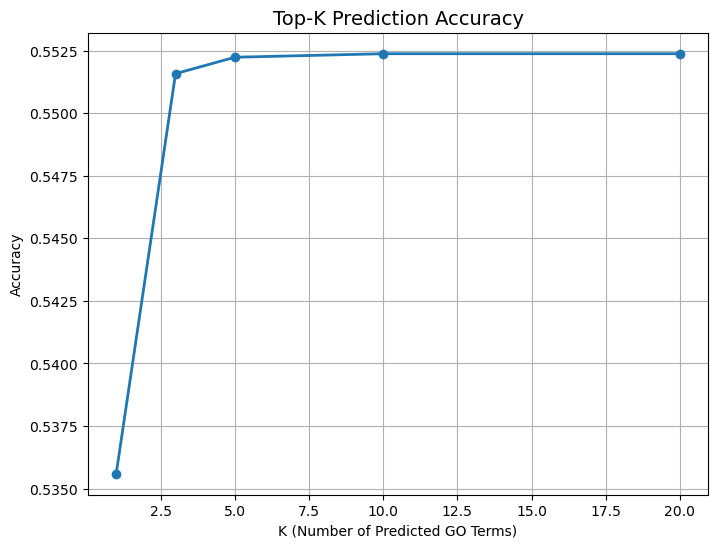


✓ Saved: visuals/top_k_accuracy.png


In [79]:
print("\n" + "="*70)
print("TOP-K PREDICTION PERFORMANCE")
print("="*70)

top_k_values = [1, 3, 5, 10, 20]
top_k_accuracy = []

for k in top_k_values:

    correct = 0
    total = len(y_mf_test)

    for i in range(total):

        # True GO labels
        true_labels = set(np.where(y_mf_test[i] == 1)[0])

        # Top-K predicted label indices
        top_k_preds = set(np.argsort(y_scores[i].ravel())[-k:])

        # Check if at least one correct label exists
        if len(true_labels.intersection(top_k_preds)) > 0:
            correct += 1

    accuracy = correct / total
    top_k_accuracy.append(accuracy)

    print(f"Top-{k} Accuracy: {accuracy:.4f}")
    # Plot
plt.figure(figsize=(8,6))
plt.plot(top_k_values, top_k_accuracy, marker='o', linewidth=2)

plt.title("Top-K Prediction Accuracy", fontsize=14)
plt.xlabel("K (Number of Predicted GO Terms)")
plt.ylabel("Accuracy")
plt.grid(True)

plt.savefig("C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/visuals/top_k_accuracy.png", dpi=300)
plt.show()

print("\n✓ Saved: visuals/top_k_accuracy.png")

In [81]:
# Cell 14: Final Summary Report
print("\n" + "="*70)
print("BASELINE MODELS - FINAL SUMMARY")
print("="*70)

summary = f"""
CAFA 5 - BASELINE MODELS EVALUATION SUMMARY

TASK: Multi-Label Classification (Molecular Function)
- Number of GO terms: {y_mf_test.shape[1]}
- Test set size: {y_mf_test.shape[0]} proteins

MODELS EVALUATED:
1. Logistic Regression (OneVsRest)
2. Random Forest (100 estimators)
3. XGBoost (100 estimators)

BEST MODEL: {best_model_name}

TEST SET PERFORMANCE (BEST MODEL):
- Hamming Loss: {test_metrics['hamming_loss']:.4f}
- Subset Accuracy: {test_metrics['subset_accuracy']:.4f}
- F1 Score (Micro): {test_metrics['f1_micro']:.4f}
- F1 Score (Macro): {test_metrics['f1_macro']:.4f}
- Precision (Micro): {test_metrics['precision_micro']:.4f}
- Recall (Micro): {test_metrics['recall_micro']:.4f}

MODEL COMPARISON (Validation F1 Micro):
- Logistic Regression: {comparison_df.loc[0, 'F1_Micro']:.4f}
- Random Forest: {comparison_df.loc[1, 'F1_Micro']:.4f}
- XGBoost: {comparison_df.loc[2, 'F1_Micro']:.4f}

PER-LABEL PERFORMANCE:
- Best performing GO term: {per_label_df.iloc[0]['GO_Term']} (F1: {per_label_df.iloc[0]['F1_Score']:.4f})
- Worst performing GO term: {per_label_df.iloc[-1]['GO_Term']} (F1: {per_label_df.iloc[-1]['F1_Score']:.4f})
- Average F1 across all GO terms: {per_label_df['F1_Score'].mean():.4f}

KEY INSIGHTS:
- Multi-label classification is challenging (low subset accuracy)
- Micro F1 > Macro F1 indicates imbalanced label distribution
- Performance correlates with label frequency (support)
- Classical ML provides strong baseline for comparison

NEXT STEPS:
1. Implement deep learning models (LSTM, CNN, Attention)
2. Use protein sequence directly (embeddings)
3. Address label imbalance (class weights, focal loss)
4. Ensemble methods (combine multiple models)
5. Extend to Biological Process and Cellular Component

FILES GENERATED:
- models/lr_model_mf.pkl
- models/rf_model_mf.pkl
- models/xgb_model_mf.pkl
- reports/baseline_model_comparison.csv
- results/y_test_pred_baseline.npy
- results/test_metrics_baseline.pkl
- results/per_label_performance.csv
- visuals/08_baseline_model_comparison.png
- visuals/09_per_label_performance.png
- visuals/10_support_vs_performance.png
- visuals/top_k_accuracy.png
BASELINE ESTABLISHED ✓
READY FOR DEEP LEARNING ✓
"""

print(summary)

# Save summary
with open('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/reports/03_baseline_models_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary)

print("\n✓ Saved: reports/03_baseline_models_summary.txt")


BASELINE MODELS - FINAL SUMMARY

CAFA 5 - BASELINE MODELS EVALUATION SUMMARY

TASK: Multi-Label Classification (Molecular Function)
- Number of GO terms: 50
- Test set size: 21337 proteins

MODELS EVALUATED:
1. Logistic Regression (OneVsRest)
2. Random Forest (100 estimators)
3. XGBoost (100 estimators)

BEST MODEL: XGBoost

TEST SET PERFORMANCE (BEST MODEL):
- Hamming Loss: 0.0490
- Subset Accuracy: 0.2367
- F1 Score (Micro): 0.4135
- F1 Score (Macro): 0.2048
- Precision (Micro): 0.6270
- Recall (Micro): 0.3085

MODEL COMPARISON (Validation F1 Micro):
- Logistic Regression: 0.3123
- Random Forest: 0.3628
- XGBoost: 0.4158

PER-LABEL PERFORMANCE:
- Best performing GO term: GO:0003674 (F1: 0.7012)
- Worst performing GO term: GO:0043168 (F1: 0.0369)
- Average F1 across all GO terms: 0.2048

KEY INSIGHTS:
- Multi-label classification is challenging (low subset accuracy)
- Micro F1 > Macro F1 indicates imbalanced label distribution
- Performance correlates with label frequency (support)
-

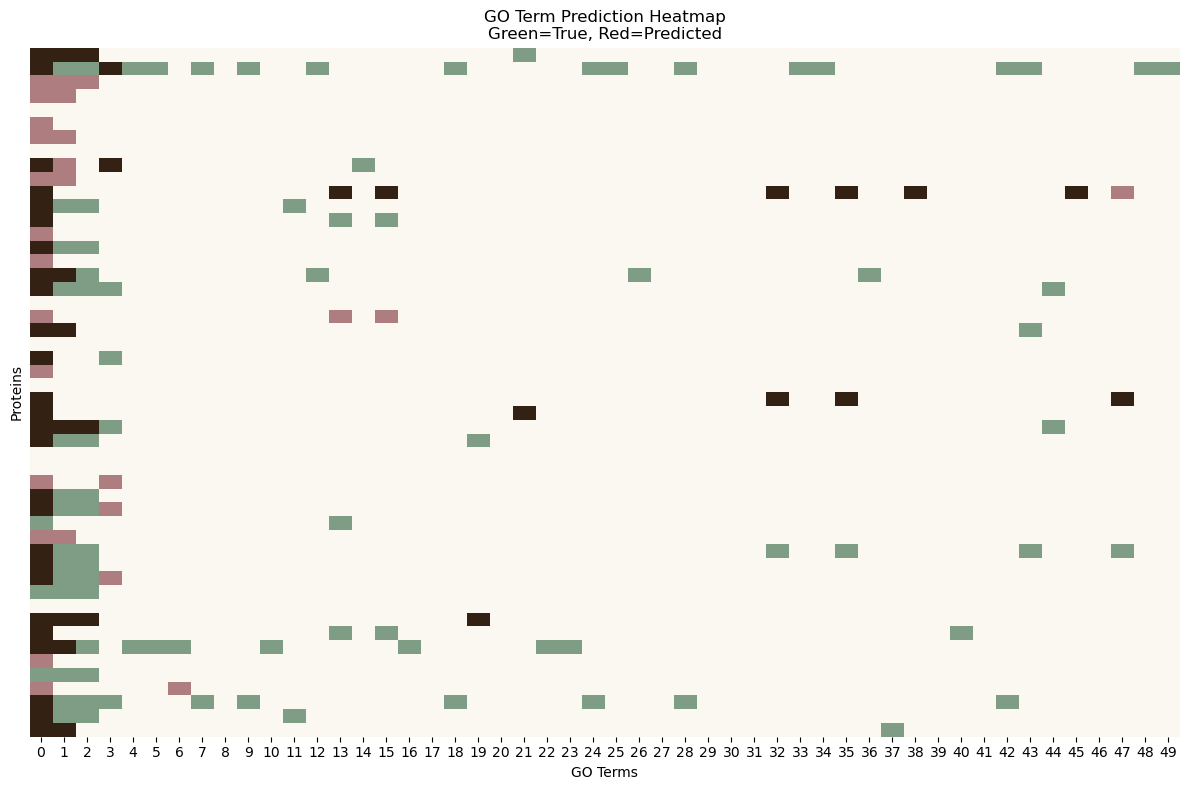

✓ Saved: go_term_heatmap.png


In [83]:
import seaborn as sns

# Select subset for visualization (e.g., first 50 proteins)
subset_size = 50
y_true_subset = y_mf_test[:subset_size]
y_pred_subset = y_test_pred[:subset_size]

plt.figure(figsize=(12, 8))
sns.heatmap(y_true_subset, cmap="Greens", cbar=False, yticklabels=False)
sns.heatmap(y_pred_subset, cmap="Reds", alpha=0.5, cbar=False, yticklabels=False)

plt.title("GO Term Prediction Heatmap\nGreen=True, Red=Predicted")
plt.xlabel("GO Terms")
plt.ylabel("Proteins")
plt.tight_layout()
plt.savefig('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/visuals/go_term_heatmap.png', dpi=300)
plt.show()
print("✓ Saved: go_term_heatmap.png")

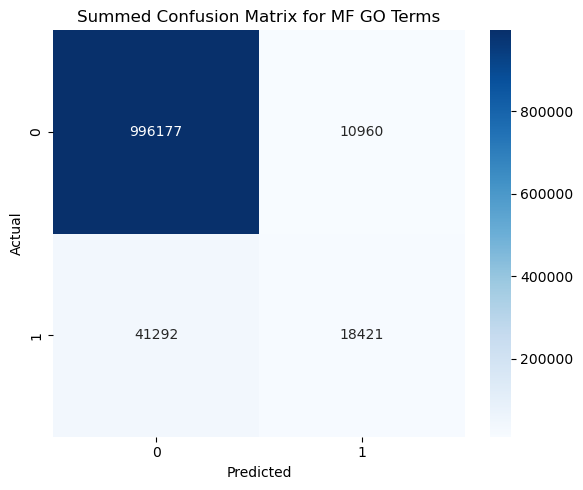

✓ Saved: confusion_matrix.png


In [90]:
from sklearn.metrics import multilabel_confusion_matrix

mcm = multilabel_confusion_matrix(y_mf_test, y_test_pred)

# Example: Summed confusion across all labels
sum_mcm = mcm.sum(axis=0)

plt.figure(figsize=(6, 5))
sns.heatmap(sum_mcm, annot=True, fmt='d', cmap="Blues")
plt.title("Summed Confusion Matrix for MF GO Terms")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/visuals/confusion_matrix.png', dpi=300)
plt.show()
print("✓ Saved: confusion_matrix.png")

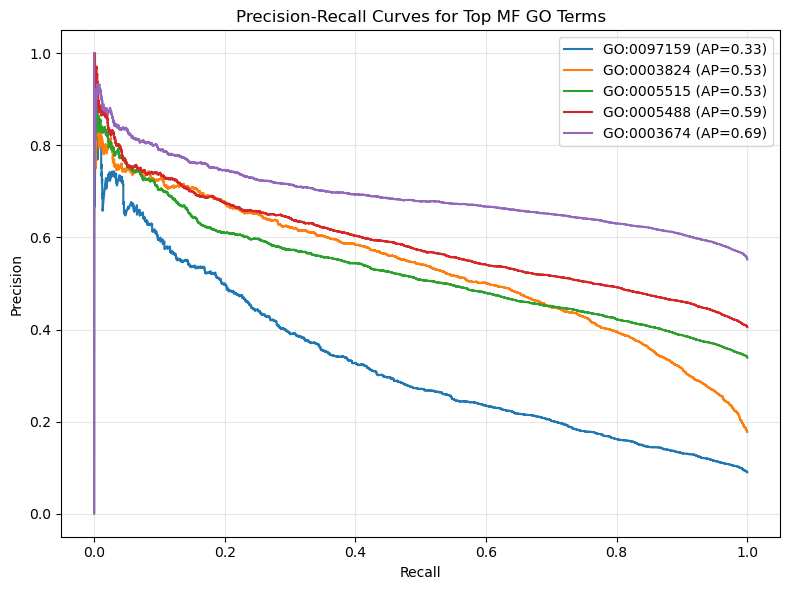

✓ Saved: pr_curves.png


In [86]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Top 5 GO terms by support
top_labels = np.argsort(y_mf_test.sum(axis=0))[-5:]

plt.figure(figsize=(8,6))
for i in top_labels:
    precision, recall, _ = precision_recall_curve(y_mf_test[:, i], y_scores[:, i])
    ap = average_precision_score(y_mf_test[:, i], y_scores[:, i])
    plt.plot(recall, precision, label=f'{mlb_mf.classes_[i]} (AP={ap:.2f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves for Top MF GO Terms")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('C:/Users/s.c/Documents/DataScience-Projects/protein-function-prediction-cafa5/visuals/pr_curves.png', dpi=300)
plt.show()
print("✓ Saved: pr_curves.png")